# Capstone Project - Stage 2, Week 3 (Module 14)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ConstantKernel
from sklearn.preprocessing import StandardScaler

from scipy.stats import norm
from scipy.spatial.distance import pdist
from scipy.stats import qmc


## Function 1

**2-dimensional**

Detect likely contamination sources in a two-dimensional area, such as a radiation field, where only proximity yields a non-zero reading. The system uses Bayesian optimisation to tune detection parameters and reliably identify both strong and weak sources.

**Approach**:

Start with high kappa, use RBF kernel.

### Loading data

In [21]:
function1_inputs = np.load('C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/Week 4/Function 1/function1_inputs_week4.npy')
print('Inputs: \n',function1_inputs)

function1_outputs = np.load('C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/Week 4/Function 1/function1_outputs_week4.npy')
print('Outputs: \n',function1_outputs)

X = function1_inputs
y = function1_outputs

Inputs: 
 [[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.912815   0.808011  ]
 [0.406375   0.98      ]
 [0.832839   0.723797  ]]
Outputs: 
 [ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048  1.33433617e-079 -1.00080319e-121
  2.41493186e-036]


#### Applying a basic GP model

c:\Python\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


The next query point is: [0.976954 0.45457 ]

Submission format:        0.976954-0.454570

The best y value observed so far is: 7.710875114502849e-16 at iteration 3, with inputs [0.73102363 0.73299988]


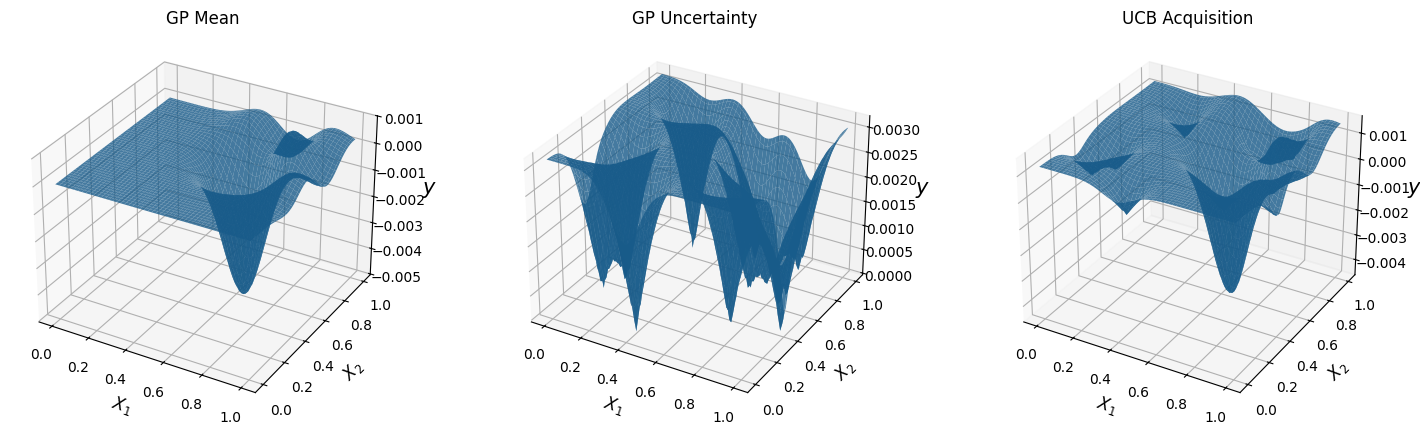

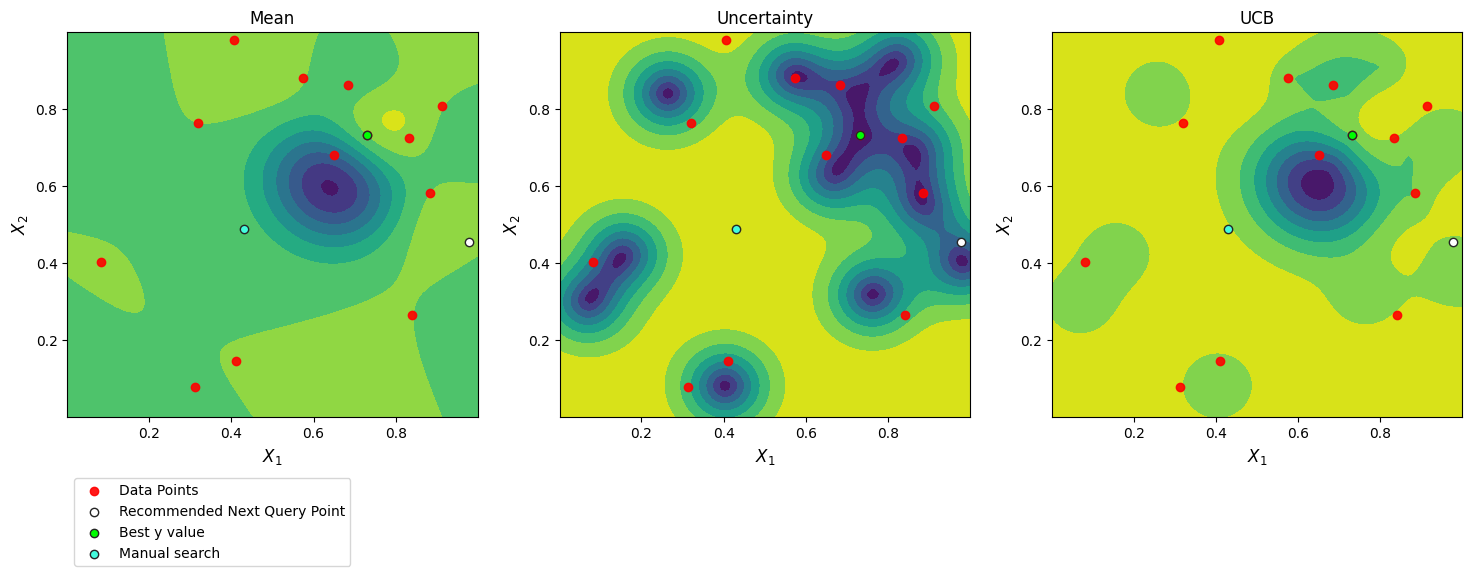

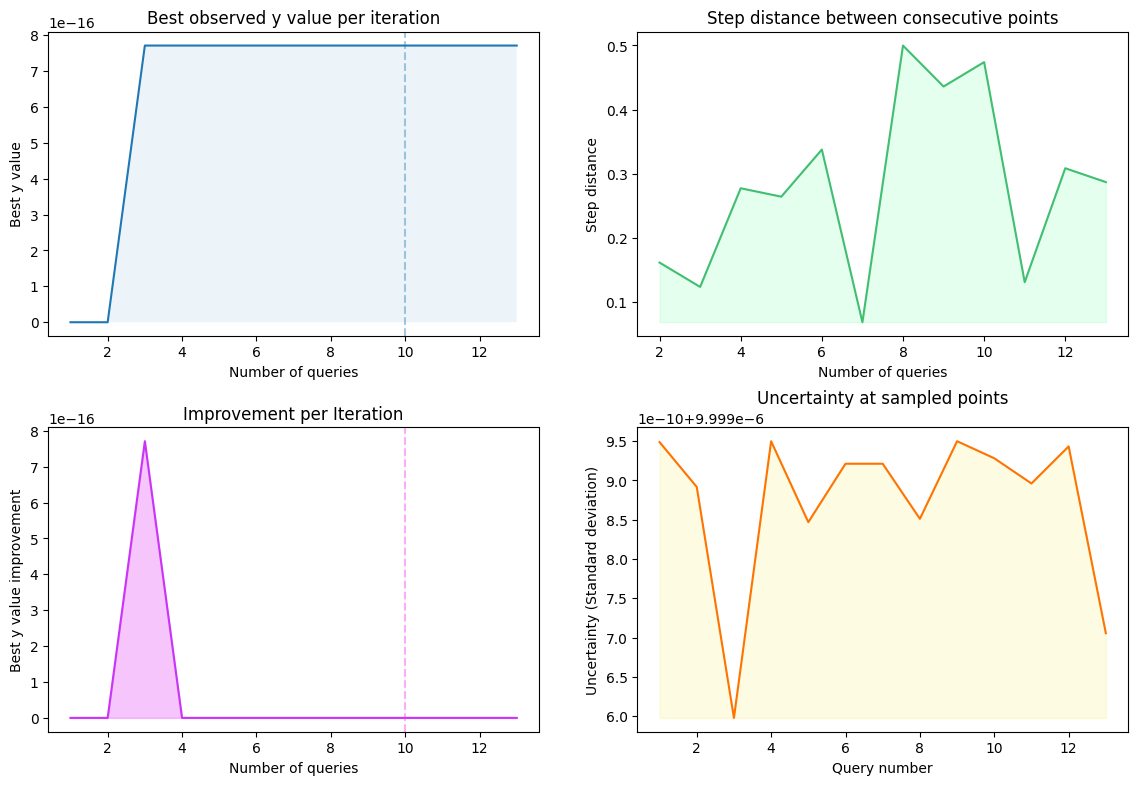

In [24]:
# Defining GP model and fitting to data
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

kernel = ConstantKernel(1.0) * RBF(length_scale=1)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=12) # Look at parameters, some are interesting like normalise y.

model = gpr.fit(X, y)

# Generating candidate points (grid search)
X_candidates = np.random.uniform(0, 1, (50000, 2))

# GP predictions
mu, sigma = model.predict(X_candidates, return_std=True)

# Acquisition function (UCB)
kappa = .4
acquisition_function = mu + kappa * sigma

# Pick next point
x_next = X_candidates[np.argmax(acquisition_function)]
print('The next query point is:', np.round(x_next, 6))

manual_search = np.array([0.43, 0.49])

submission = f"{x_next[0]:.6f}-{x_next[1]:.6f}"
print('\nSubmission format:       ', submission)



# ==== Metrics ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

# Best value
best_value1_rolling = np.maximum.accumulate(y)   #Returns a rolling value of the best observed y value
best_value1 = max(best_value1_rolling)           #Returns the value of the best observed y value
best_value1_index = best_value1_rolling.argmax() #Returns the index of the best observed y value
best_value1_inputs = X[best_value1_index]        #Returns the inputs that correspond to the best observed y value

print(f'\nThe best y value observed so far is: {best_value1} at iteration {best_value1_index + 1}, with inputs {best_value1_inputs}')

# Improvement per step
best_previous = np.roll(best_value1_rolling, 1)
best_previous[0] = y[0]

improvement = np.maximum(0, y - best_previous)

# Distance between sampled points
distances = pdist(X)
avg_distances = np.mean(distances)
min_distance = np.min(distances)

# Step distance between consecutive points
step_dist = np.zeros((len(X)+1))
step_dist[:2] = np.nan
for i in range(1, len(X)):
    step_dist[i+1] = np.linalg.norm(X[i] - X[i-1])
step_dist_normalised = step_dist / np.sqrt(3)
step_dist_min = step_dist_normalised[2:].min()

# Uncertainty at sampled points
mu_selected, sigma_selected = model.predict(X, return_std=True)




# ==== Visualising Results ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

# Meshgrid - using grid for plotting but not for actual predictions.

epsilon = 1e-3
x1 = np.linspace(0+epsilon, 1-epsilon, 100)
x2 = np.linspace(0+epsilon, 1-epsilon, 100)

x_grid = np.array([[a, b] for a in x1 for b in x2])

mu_plot, sigma_plot = model.predict(x_grid, return_std=True)

acquisition_plot = mu_plot + kappa * sigma_plot

X1, X2 = np.meshgrid(x1, x2)
X_grid = np.vstack([X1.ravel(), X2.ravel()]).T

# Reshaping
mu = mu_plot.reshape(X1.shape)
sigma = sigma_plot.reshape(X1.shape)
ucb = acquisition_plot.reshape(X1.shape)


# Mesh plots
# ‾‾‾‾‾‾‾‾‾‾

fig = plt.figure(figsize=(18, 5))

# Mean
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(X1, X2, mu, alpha=0.8)
ax1.set_xlabel('$X_1$', size=12)
ax1.set_ylabel('$X_2$', size=12)
ax1.set_zlabel('$y$', size=15)
ax1.set_title("GP Mean")

# Uncertainty
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(X1, X2, sigma, alpha=0.8)
ax2.set_xlabel('$X_1$', size=12)
ax2.set_ylabel('$X_2$', size=12)
ax2.set_zlabel('$y$', size=15)
ax2.set_title("GP Uncertainty")

# Acquisition
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_surface(X1, X2, ucb, alpha=0.8)
ax3.set_xlabel('$X_1$', size=12)
ax3.set_ylabel('$X_2$', size=12)
ax3.set_zlabel('$y$', size=15)
ax3.set_title("UCB Acquisition")


# Contour plots
# ‾‾‾‾‾‾‾‾‾‾‾‾‾

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].contourf(X1, X2, mu)
axs[0].scatter(X[:,0], X[:,1], c='red', alpha=0.9, label='Data Points')
axs[0].scatter(x_next[0], x_next[1], c='#FFFFFF', label='Recommended Next Query Point', edgecolors='#252525')
axs[0].scatter(best_value1_inputs[0], best_value1_inputs[1], c='#00FF00', label='Best y value', edgecolors="#252525")
axs[0].scatter(manual_search[0], manual_search[1], c="#43FCDD", label='Manual search', edgecolors="#252525")
axs[0].set_xlabel('$X_1$', size=12)
axs[0].set_ylabel('$X_2$', size=12)
axs[0].set_title("Mean")
axs[0].legend(loc='upper left', bbox_to_anchor=(0, -0.14))

axs[1].contourf(X1, X2, sigma)
axs[1].scatter(X[:,0], X[:,1], c='red', alpha=0.9)
axs[1].scatter(x_next[0], x_next[1], c='#FFFFFF', edgecolors="#252525")
axs[1].scatter(best_value1_inputs[0], best_value1_inputs[1], c='#00FF00', edgecolors="#252525")
axs[1].scatter(manual_search[0], manual_search[1], c="#43FCDD", label='Manual search', edgecolors="#252525")
axs[1].set_xlabel('$X_1$', size=12)
axs[1].set_ylabel('$X_2$', size=12)
axs[1].set_title("Uncertainty")

axs[2].contourf(X1, X2, ucb)
axs[2].scatter(X[:,0], X[:,1], c='red', alpha=0.9)
axs[2].scatter(x_next[0], x_next[1], c='#FFFFFF', edgecolors="#252525")
axs[2].scatter(best_value1_inputs[0], best_value1_inputs[1], c='#00FF00',  edgecolors="#252525")
axs[2].scatter(manual_search[0], manual_search[1], c="#43FCDD", label='Manual search', edgecolors="#252525")
axs[2].set_xlabel('$X_1$', size=12)
axs[2].set_ylabel('$X_2$', size=12)
axs[2].set_title("UCB")


# Performance tracking plots
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

fig, axes = plt.subplots(2,2, figsize=(18, 10))

# Optimisation curve
axes[0,0].plot(np.arange(1,len(X)+1,1), best_value1_rolling)
axes[0,0].axvline(10, linestyle='--', alpha=0.4)
axes[0,0].set_xlabel('Number of queries')
axes[0,0].set_ylabel('Best y value')
axes[0,0].set_title('Best observed y value per iteration')
axes[0,0].fill_between(np.arange(1,len(X)+1,1), best_value1_rolling, best_value1_rolling.min(), alpha=0.08)

# Improvement per step
axes[1,0].plot(np.arange(1,len(X)+1,1), improvement, color="#CA33F8")
axes[1,0].axvline(10, linestyle='--', color="#F833EE",alpha=0.4)
axes[1,0].set_xlabel('Number of queries')
axes[1,0].set_ylabel('Best y value improvement')
axes[1,0].set_title('Improvement per Iteration')
axes[1,0].fill_between(np.arange(1,len(X)+1,1), improvement, improvement.min(), color="#E040F5", alpha=0.3)

# Step distances
axes[0,1].plot(step_dist_normalised, c="#41BE71")
axes[0,1].set_xlabel('Number of queries')
axes[0,1].set_ylabel('Step distance')
axes[0,1].set_title('Step distance between consecutive points')
axes[0,1].fill_between(np.arange(0,len(step_dist),1), step_dist_normalised, step_dist_min, color='#05FF65',alpha=0.1)

# Uncertainty at sampled points
axes[1,1].plot(np.arange(1,len(sigma_selected)+1,1), sigma_selected, c="#FF7300")
axes[1,1].set_xlabel('Query number')
axes[1,1].set_ylabel('Uncertainty (Standard deviation)')
axes[1,1].set_title('Uncertainty at sampled points')
axes[1,1].fill_between(np.arange(1,len(sigma_selected)+1,1), sigma_selected, sigma_selected.min(), color="#F8E539", alpha=0.15)

# Formatting plots
plt.subplots_adjust(
    left=0.2,
    right=0.8,
    top=0.85,
    bottom=0.15,
    hspace=0.3,
    wspace=0.2
)

plt.show()

## Function 2

**2-dimensional**

Imagine a black box, or a mystery ML model, that takes two numbers as input and returns a log-likelihood score. Your goal is to maximise that score, but each output is noisy, and depending on where you start, you might get stuck in a local optimum. 
To tackle this, you use Bayesian optimisation, which selects the next inputs based on what it has learned so far. It balances exploration with exploitation, making it well suited to noisy outputs and complex functions with many local peaks.

**Approach**:

Potentially multiple peaks, start with high kappa. RBF kernel.

#### Importing data

In [25]:
function2_inputs = np.load('C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/Week 4/Function 2/function2_inputs_week4.npy')
print('Inputs: \n', function2_inputs)

function2_outputs = np.load('C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/Week 4/Function 2/function2_outputs_week4.npy')
print('Outputs: \n',function2_outputs)

X = function2_inputs
y = function2_outputs

print(len(X), len(y))

y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.reshape(-1,1)).ravel()

Inputs: 
 [[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]
 [0.21       0.8       ]
 [0.6        0.42      ]
 [0.800537   0.921613  ]]
Outputs: 
 [ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522 -0.03462578  0.02460055
  0.11093379]
13 13


#### Surrogate and Acquisition functions

The next query point is: [0.673479 0.928902]

Submission format:        0.673479-0.928902

The best y value observed so far is: 0.6112052157614438 at iteration 10, with inputs [0.70263656 0.9265642 ]


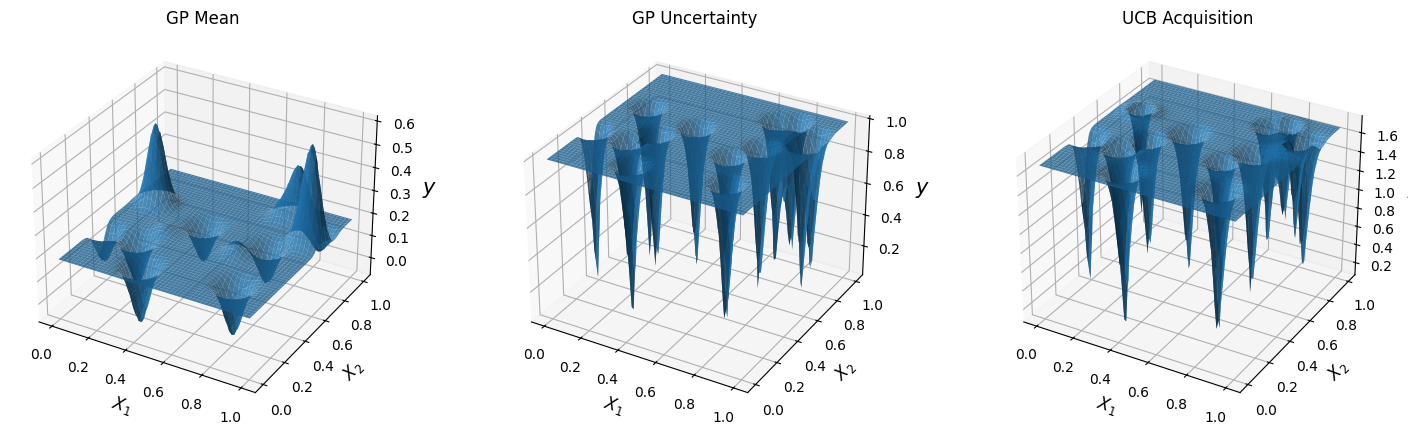

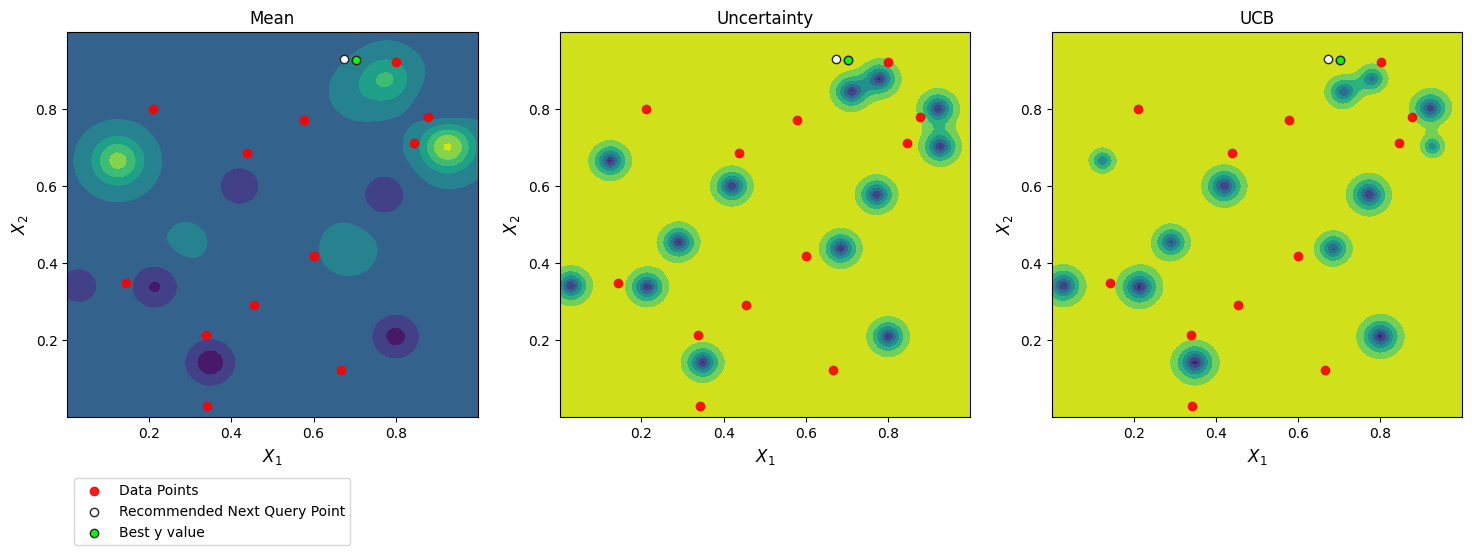

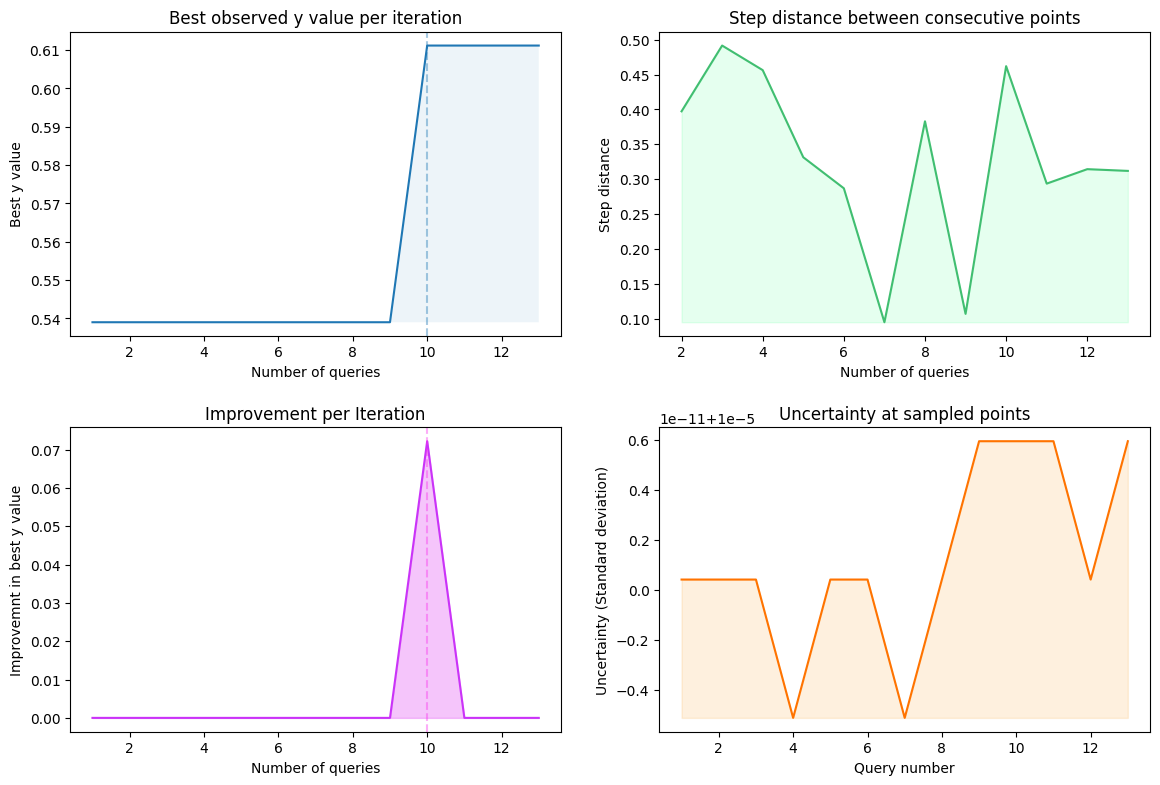

In [27]:
# Defining GP model and fitting to data
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

kernel = ConstantKernel(1.0) * RBF(length_scale=1)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=15) # Look at parameters, some are interesting like normalise y.

model = gpr.fit(X, y_scaled)

# Generating candidate points (grid search)
X_candidates = np.random.uniform(0, 1, (40000, 2))

# GP predictions
mu, sigma = model.predict(X_candidates, return_std=True)

# Acquisition function (UCB)
kappa = 1.5
acquisition_function = mu + kappa * sigma

# Pick next point
x_next = X_candidates[np.argmax(acquisition_function)]
print('The next query point is:', np.round(x_next,6))

submission = f"{x_next[0]:.6f}-{x_next[1]:.6f}"
print('\nSubmission format:       ', submission)

#manual_search = [0.01,0.01]


# ==== Metrics ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

# Best value
best_value2_rolling = np.maximum.accumulate(y)   #Returns a rolling value of the best observed y value
best_value2 = max(best_value2_rolling)           #Returns the value of the best observed y value
best_value2_index = best_value2_rolling.argmax() #Returns the index of the best observed y value
best_value2_inputs = X[best_value2_index]        #Returns the inputs that correspond to the best observed y value

print(f'\nThe best y value observed so far is: {best_value2} at iteration {best_value2_index + 1}, with inputs {best_value2_inputs}')

# Improvement per step
best_previous = np.roll(best_value2_rolling, 1)
best_previous[0] = y[0]

improvement = np.maximum(0, y - best_previous)

# Distance between sampled points
distances = pdist(X)
avg_distances = np.mean(distances)
min_distance = np.min(distances)

# Step distance between consecutive points
step_dist = np.zeros((len(X)+1))
step_dist[:2] = np.nan
for i in range(1, len(X)):
    step_dist[i+1] = np.linalg.norm(X[i] - X[i-1])
step_dist_normalised = step_dist / np.sqrt(3)
step_dist_min = step_dist_normalised[2:].min()

# Uncertainty at sampled points
mu_selected, sigma_selected = model.predict(X, return_std=True)



# ==== Visualising Results ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

# Meshgrid - using grid for plotting but not for actual predictions.

epsilon = 1e-3
x1 = np.linspace(0+epsilon, 1-epsilon, 100)
x2 = np.linspace(0+epsilon, 1-epsilon, 100)

x_grid = np.array([[a, b] for a in x1 for b in x2])

mu_plot_scaled, sigma_plot = model.predict(x_grid, return_std=True)

# Unscaling mu for plotting
mu_plot = y_scaler.inverse_transform(mu_plot_scaled.reshape(-1,1)).ravel()

acquisition_plot = mu_plot + kappa * sigma_plot

X1, X2 = np.meshgrid(x1, x2)
X_grid = np.vstack([X1.ravel(), X2.ravel()]).T

# Reshaping
mu = mu_plot.reshape(X1.shape)
sigma = sigma_plot.reshape(X1.shape)
ucb = acquisition_plot.reshape(X1.shape)

# Mesh plots
# ‾‾‾‾‾‾‾‾‾‾

fig = plt.figure(figsize=(18, 5))

# Mean
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(X1, X2, mu, alpha=0.8)
ax1.set_xlabel('$X_1$', size=12)
ax1.set_ylabel('$X_2$', size=12)
ax1.set_zlabel('$y$', size=15)
ax1.set_title("GP Mean")

# Uncertainty
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(X1, X2, sigma, alpha=0.8)
ax2.set_xlabel('$X_1$', size=12)
ax2.set_ylabel('$X_2$', size=12)
ax2.set_zlabel('$y$', size=15)
ax2.set_title("GP Uncertainty")

# Acquisition
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_surface(X1, X2, ucb, alpha=0.8)
ax3.set_xlabel('$X_1$', size=12)
ax3.set_ylabel('$X_2$', size=12)
ax3.set_zlabel('$y$', size=15)
ax3.set_title("UCB Acquisition")


# Contour plots
# ‾‾‾‾‾‾‾‾‾‾‾‾‾

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].contourf(X1, X2, mu)
axs[0].scatter(X[:,0], X[:,1], c='red', alpha=0.9, label='Data Points')
axs[0].scatter(x_next[0], x_next[1], c='#FFFFFF', label='Recommended Next Query Point', edgecolors='#252525')
axs[0].scatter(best_value2_inputs[0], best_value2_inputs[1], c='#00FF00', label='Best y value', edgecolors='#252525')
#axs[0].scatter(manual_search[0], manual_search[1], c="#FFFFFF") #Used in first two submissions to visualise manual search
axs[0].set_xlabel('$X_1$', size=12)
axs[0].set_ylabel('$X_2$', size=12)
axs[0].set_title("Mean")
axs[0].legend(loc='upper left', bbox_to_anchor=(0, -0.14))

axs[1].contourf(X1, X2, sigma)
axs[1].scatter(X[:,0], X[:,1], c='red', alpha=0.9)
axs[1].scatter(x_next[0], x_next[1], c='#FFFFFF', edgecolors='#252525')
axs[1].scatter(best_value2_inputs[0], best_value2_inputs[1], c='#00FF00', edgecolors='#252525')
#axs[1].scatter(manual_search[0], manual_search[1], c="#FFFFFF") #Used in first two submissions visualise manual search
axs[1].set_xlabel('$X_1$', size=12)
axs[1].set_ylabel('$X_2$', size=12)
axs[1].set_title("Uncertainty")

axs[2].contourf(X1, X2, ucb)
axs[2].scatter(X[:,0], X[:,1], c='red', alpha=0.9)
axs[2].scatter(x_next[0], x_next[1], c='#FFFFFF', edgecolors='#252525')
axs[2].scatter(best_value2_inputs[0], best_value2_inputs[1], c='#00FF00', edgecolors='#252525')
#axs[2].scatter(manual_search[0], manual_search[1], c="#FFFFFF")
axs[2].set_xlabel('$X_1$', size=12)
axs[2].set_ylabel('$X_2$', size=12)
axs[2].set_title("UCB")

# Performance tracking plots
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

fig, axes = plt.subplots(2,2, figsize=(18, 10))

# Optimisation curve
axes[0,0].plot(np.arange(1,len(X)+1,1), best_value2_rolling)
axes[0,0].axvline(10, linestyle='--', alpha=0.4)
axes[0,0].set_xlabel('Number of queries')
axes[0,0].set_ylabel('Best y value')
axes[0,0].set_title('Best observed y value per iteration')
axes[0,0].fill_between(np.arange(1,len(X)+1,1), best_value2_rolling, best_value2_rolling.min(), alpha=0.08)

# Improvement per step
axes[1,0].plot(np.arange(1,len(X)+1,1), improvement, color="#CA33F8")
axes[1,0].axvline(10, linestyle='--', color="#F833EE",alpha=0.4)
axes[1,0].set_xlabel('Number of queries')
axes[1,0].set_ylabel('Improvemnt in best y value')
axes[1,0].set_title('Improvement per Iteration')
axes[1,0].fill_between(np.arange(1,len(X)+1,1), improvement, improvement.min(), color="#E040F5", alpha=0.3)

# Step distances
axes[0,1].plot(step_dist_normalised, c="#41BE71")
axes[0,1].set_xlabel('Number of queries')
axes[0,1].set_ylabel('Step distance')
axes[0,1].set_title('Step distance between consecutive points')
axes[0,1].fill_between(np.arange(0,len(step_dist),1), step_dist_normalised, step_dist_min, color='#05FF65',alpha=0.1)

# Uncertainty at sampled points
axes[1,1].plot(np.arange(1,len(sigma_selected)+1,1), sigma_selected, c="#FF7300")
axes[1,1].set_xlabel('Query number')
axes[1,1].set_ylabel('Uncertainty (Standard deviation)')
axes[1,1].set_title('Uncertainty at sampled points')
axes[1,1].fill_between(np.arange(1,len(sigma_selected)+1,1), sigma_selected, sigma_selected.min(), color="#FC9F27", alpha=0.15)

# Formatting plots
plt.subplots_adjust(
    left=0.2,
    right=0.8,
    top=0.85,
    bottom=0.15,
    hspace=0.3,
    wspace=0.2
)

plt.show()

## Function 3

**3-dimensional**

You’re working on a drug discovery project, testing combinations of three compounds to create a new medicine.
Each experiment is stored in initial_inputs.npy as a 3D array, where each row lists the amounts of the three compounds used. After each experiment, you record the number of adverse reactions, stored in initial_outputs.npy as a 1D array.
Your goal is to minimise side effects; in this competition, it is framed as maximisation by optimising a transformed output (e.g. the negative of side effects). 

**Approach**:

Start with high kappa, RBF kernel.

In [9]:
function3_inputs = np.load('C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/Week 4/Function 3/function3_inputs_week4.npy')
print('Inputs: \n', function3_inputs)

function3_outputs = np.load('C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/Week 4/Function 3/function3_outputs_week4.npy')
print('Outputs: \n',function3_outputs)

X = function3_inputs
y = function3_outputs

print(len(X), len(y))

y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.reshape(-1,1)).ravel()


Inputs: 
 [[0.17152521 0.34391687 0.2487372 ]
 [0.24211446 0.64407427 0.27243281]
 [0.53490572 0.39850092 0.17338873]
 [0.49258141 0.61159319 0.34017639]
 [0.13462167 0.21991724 0.45820622]
 [0.34552327 0.94135983 0.26936348]
 [0.15183663 0.43999062 0.99088187]
 [0.64550284 0.39714294 0.91977134]
 [0.74691195 0.28419631 0.22629985]
 [0.17047699 0.6970324  0.14916943]
 [0.22054934 0.29782524 0.34355534]
 [0.66601366 0.67198515 0.2462953 ]
 [0.04680895 0.23136024 0.77061759]
 [0.60009728 0.72513573 0.06608864]
 [0.96599485 0.86111969 0.56682913]
 [0.51764    0.004569   0.569925  ]
 [0.891717   0.852251   0.371034  ]
 [0.414483   0.061504   0.530133  ]]
Outputs: 
 [-0.1121222  -0.08796286 -0.11141465 -0.03483531 -0.04800758 -0.11062091
 -0.39892551 -0.11386851 -0.13146061 -0.09418956 -0.04694741 -0.10596504
 -0.11804826 -0.03637783 -0.05675837 -0.09884205 -0.06638201 -0.08545748]
18 18


The next query point is: [0.430025 0.43138  0.511326]

Submission format:        0.430025-0.431380-0.511326

The best y value observed so far is: -0.034835313350078584 at iteration 4, with inputs [0.49258141 0.61159319 0.34017639]


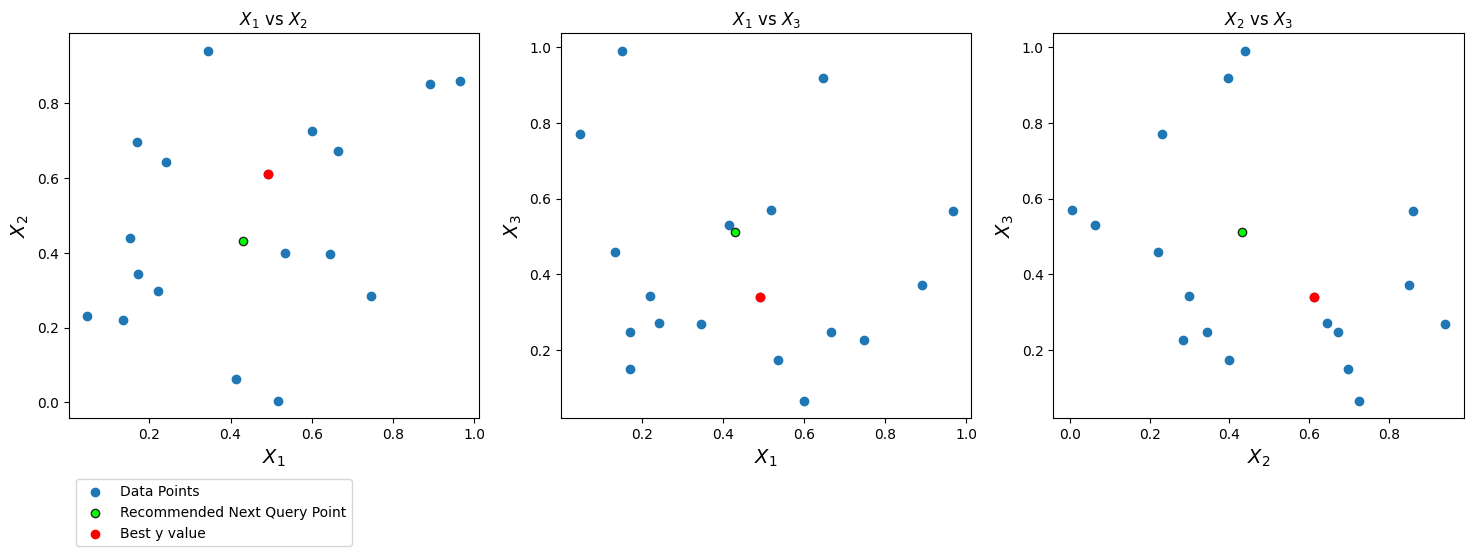

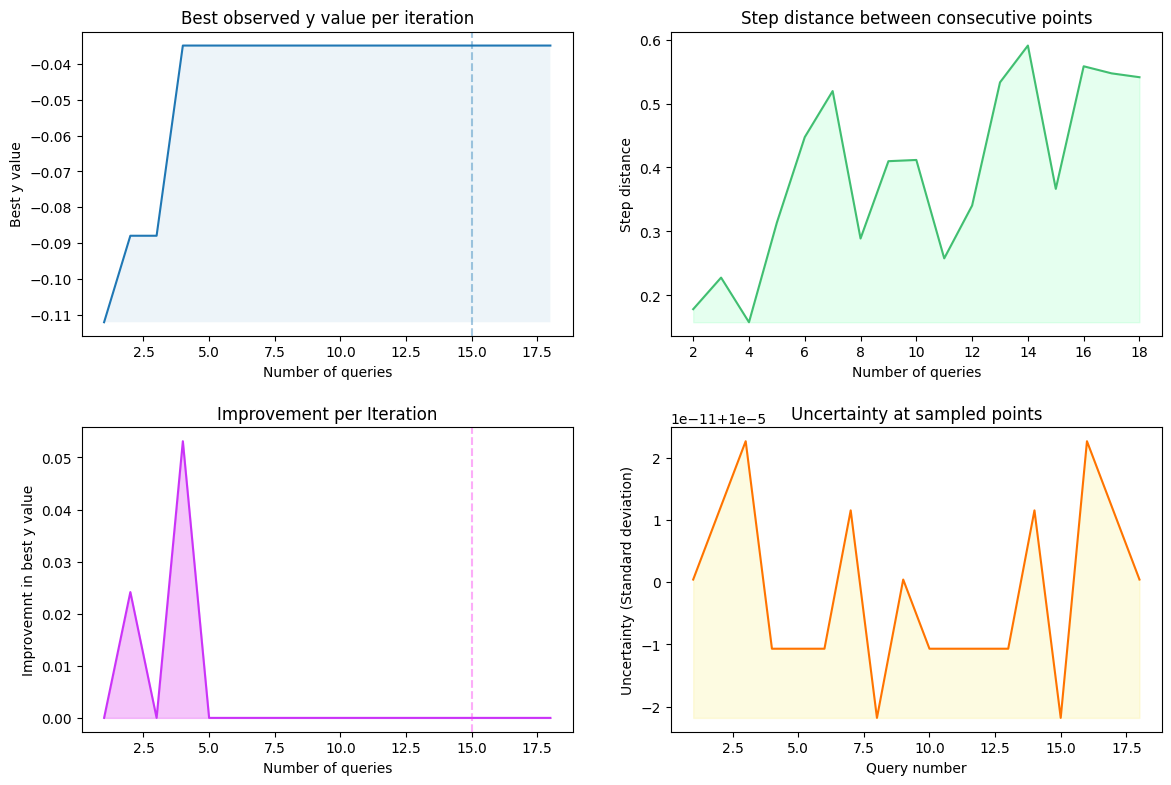

In [10]:
# Defining GP model and fitting to data
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

kernel = ConstantKernel(1.0) * RBF(length_scale=1)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9) # Look at parameters, some are interesting like normalise y.

model = gpr.fit(X, y_scaled)


# Generating candidate points (grid search)
X_candidates = np.random.uniform(0, 1, (20000, 3))

# GP predictions
mu, sigma = model.predict(X_candidates, return_std=True)

# Acquisition function (UCB)
kappa = 1.5
acquisition_function = mu + kappa * sigma

# Pick next point
x_next = X_candidates[np.argmax(acquisition_function)]
print('The next query point is:', np.round(x_next,6))

submission = f"{x_next[0]:.6f}-{x_next[1]:.6f}-{x_next[2]:.6f}"
print('\nSubmission format:       ', submission)



# ==== Metrics ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

# Best value
best_value3_rolling = np.maximum.accumulate(y)   #Returns a rolling value of the best observed y value
best_value3 = max(best_value3_rolling)           #Returns the value of the best observed y value
best_value3_index = best_value3_rolling.argmax() #Returns the index of the best observed y value
best_value3_inputs = X[best_value3_index]        #Returns the inputs that correspond to the best observed y value

print(f'\nThe best y value observed so far is: {best_value3} at iteration {best_value3_index + 1}, with inputs {best_value3_inputs}')

# Improvement per step
best_previous = np.roll(best_value3_rolling, 1)
best_previous[0] = y[0]

improvement = np.maximum(0, y - best_previous)

# Distance between sampled points
distances = pdist(X)
avg_distances = np.mean(distances)
min_distance = np.min(distances)

# Step distance between consecutive points
step_dist = np.zeros((len(X)+1))
step_dist[:2] = np.nan
for i in range(1, len(X)):
    step_dist[i+1] = np.linalg.norm(X[i] - X[i-1])
step_dist_normalised = step_dist / np.sqrt(3)
step_dist_min = step_dist_normalised[2:].min()

# Uncertainty at sampled points
mu_selected, sigma_selected = model.predict(X, return_std=True)



# ==== Visualisation ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

# Pair scatter plots
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
fig, axes = plt.subplots(1,3, figsize=(18, 5))

axes[0].scatter(X[:,0], X[:,1], label='Data Points')
axes[0].scatter(x_next[0], x_next[1], c='#00FF00', label='Recommended Next Query Point', edgecolors='#252525')
axes[0].scatter(best_value3_inputs[0], best_value3_inputs[1], c="red", label='Best y value')
axes[0].set_xlabel('$X_1$', size=14)
axes[0].set_ylabel('$X_2$', size=14)
axes[0].set_title('$X_1$ vs $X_2$')
axes[0].legend(loc='upper left', bbox_to_anchor=(0, -0.14))

axes[1].scatter(X[:,0], X[:,2])
axes[1].scatter(x_next[0], x_next[2], c='#00FF00', edgecolors='#252525')
axes[1].scatter(best_value3_inputs[0], best_value3_inputs[2], c='red')
axes[1].set_xlabel('$X_1$',size=14)
axes[1].set_ylabel('$X_3$',size=14)
axes[1].set_title('$X_1$ vs $X_3$')

axes[2].scatter(X[:,1], X[:,2])
axes[2].scatter(x_next[1], x_next[2], c='#00FF00', edgecolors='#252525')
axes[2].scatter(best_value3_inputs[1], best_value3_inputs[2], c='red')
axes[2].set_xlabel('$X_2$',size=14)
axes[2].set_ylabel('$X_3$',size=14)
axes[2].set_title('$X_2$ vs $X_3$')


# Performance tracking plots
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

fig, axes = plt.subplots(2,2, figsize=(18, 10))

# Optimisation curve
axes[0,0].plot(np.arange(1,len(X)+1,1), best_value3_rolling)
axes[0,0].axvline(15, linestyle='--', alpha=0.4)
axes[0,0].set_xlabel('Number of queries')
axes[0,0].set_ylabel('Best y value')
axes[0,0].set_title('Best observed y value per iteration')
axes[0,0].fill_between(np.arange(1,len(X)+1,1), best_value3_rolling, best_value3_rolling.min(), alpha=0.08)

# Improvement per step
axes[1,0].plot(np.arange(1,len(X)+1,1), improvement, color="#CA33F8")
axes[1,0].axvline(15, linestyle='--', color="#F833EE",alpha=0.4)
axes[1,0].set_xlabel('Number of queries')
axes[1,0].set_ylabel('Improvemnt in best y value')
axes[1,0].set_title('Improvement per Iteration')
axes[1,0].fill_between(np.arange(1,len(X)+1,1), improvement, improvement.min(), color="#E040F5", alpha=0.3)

# Step distances
axes[0,1].plot(step_dist_normalised, c="#41BE71")
axes[0,1].set_xlabel('Number of queries')
axes[0,1].set_ylabel('Step distance')
axes[0,1].set_title('Step distance between consecutive points')
axes[0,1].fill_between(np.arange(0,len(step_dist),1), step_dist_normalised, step_dist_min, color='#05FF65',alpha=0.1)

# Uncertainty at sampled points
axes[1,1].plot(np.arange(1,len(sigma_selected)+1,1), sigma_selected, c="#FF7300")
axes[1,1].set_xlabel('Query number')
axes[1,1].set_ylabel('Uncertainty (Standard deviation)')
axes[1,1].set_title('Uncertainty at sampled points')
axes[1,1].fill_between(np.arange(1,len(sigma_selected)+1,1), sigma_selected, sigma_selected.min(), color="#F8E539", alpha=0.15)

# Formatting plots
plt.subplots_adjust(
    left=0.2,
    right=0.8,
    top=0.85,
    bottom=0.15,
    hspace=0.3,
    wspace=0.2
)

plt.show()

## Function 4

**4-dimensional**

Address the challenge of optimally placing products across warehouses for a business with high online sales, where accurate calculations are costly and only feasible biweekly. To speed up decision-making, an ML model approximates these results within hours. The model has four hyperparameters to tune, and its output reflects the difference from the expensive baseline. Because the system is dynamic and full of local optima, it requires careful tuning and robust validation to find reliable, near-optimal solutions.

**Approach**:

Many maxima - start with high kappa and slower decay, add random exploration.
Kernel - Matern(v=1.5 or 2.5) since the function is less smooth.

In [11]:
function4_inputs = np.load('C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/Week 4/Function 4/function4_inputs_week4.npy')
print('Inputs: \n', function4_inputs)

function4_outputs = np.load('C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/Week 4/Function 4/function4_outputs_week4.npy')
print('Outputs: \n',function4_outputs)

X = function4_inputs
y = function4_outputs

print(len(X), len(y))

y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.reshape(-1,1)).ravel()

Inputs: 
 [[0.89698105 0.72562797 0.17540431 0.70169437]
 [0.8893564  0.49958786 0.53926886 0.50878344]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.80130271 0.50023109 0.70664456 0.19510284]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.74670224 0.7570915  0.36935306 0.20656628]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.6260706  0.58675126 0.43880578 0.77885769]
 [0.95713529 0.59764438 0.76611385 0.77620991]
 [0.73281243 0.14524998 0.47681272 0.13336573]
 [0.65511548 0.07239183 0.68715175 0.08151656]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.48859419 0.2119651  0.93917791 0.37619173]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.98562189 0.66693268 0.15678328 0.8565348 ]
 [0.03782483 0.66485335 0.16198218 0.25392378]
 [0.68348638 0.9027701  0.33541983 0.99948256]
 [0

The next query point is: [0.37342  0.424425 0.388801 0.473351]

Submission format:        0.373420-0.424425-0.388801-0.473351

The best y value observed so far is: 0.11560165275106771 at iteration 33, with inputs [0.423825 0.446901 0.400751 0.401047]


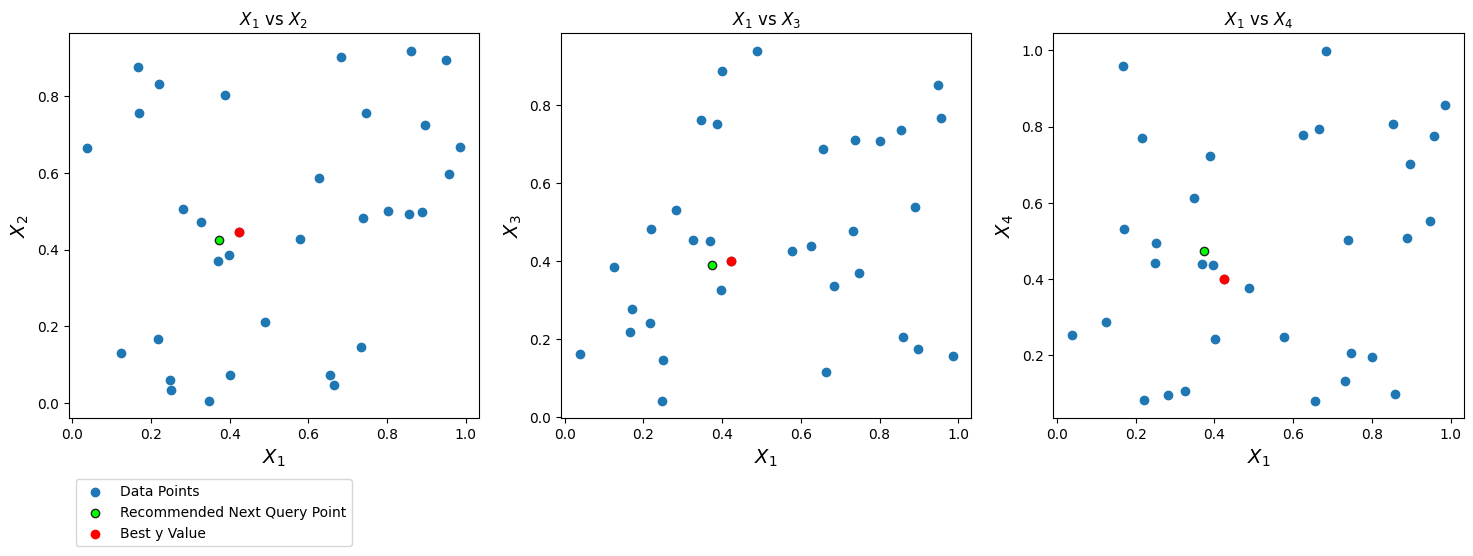

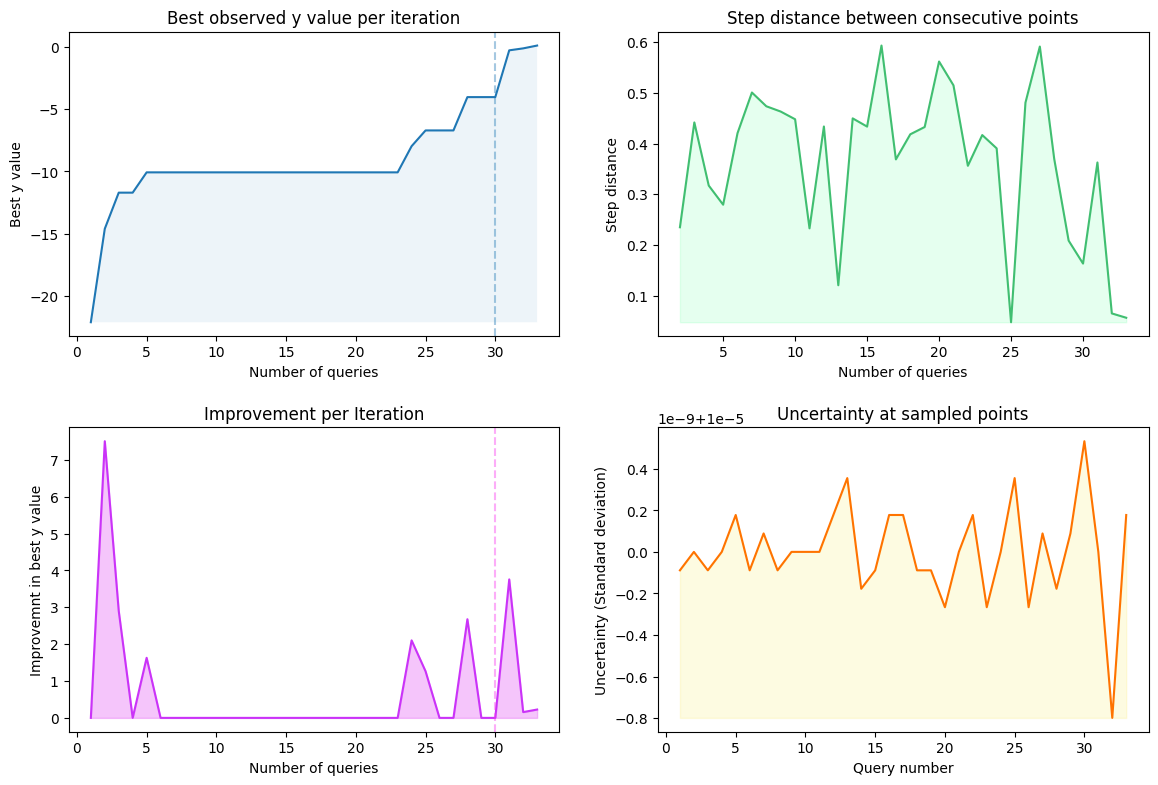

In [12]:
# Defining GP model and fitting to data
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

kernel = ConstantKernel(1.0) * Matern(length_scale=1, nu=2.5)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9) # Look at parameters, some are interesting like normalise y.

model = gpr.fit(X, y_scaled)

# Generating candidate points - smart search, scales much better in higher dimensions.
#X_candidates = np.random.uniform(0,1,(5000, 4))
sampler = qmc.Sobol(4) # Using smarter sampling
X_candidates = sampler.random(2**15)

# GP predictions
mu, sigma = model.predict(X_candidates, return_std=True)

# Acquisition function (UCB)
kappa = 2
acquisition_function = mu + kappa * sigma 

# Pick next point
x_next = X_candidates[np.argmax(acquisition_function)]
print('The next query point is:', np.round(x_next,6))

submission = f"{x_next[0]:.6f}-{x_next[1]:.6f}-{x_next[2]:.6f}-{x_next[3]:.6f}"
print('\nSubmission format:       ', submission)


# ==== Metrics ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

# Best value
best_value4_rolling = np.maximum.accumulate(y)   #Returns a rolling value of the best observed y value
best_value4 = max(best_value4_rolling)           #Returns the value of the best observed y value
best_value4_index = best_value4_rolling.argmax() #Returns the index of the best observed y value
best_value4_inputs = X[best_value4_index]        #Returns the inputs that correspond to the best observed y value

print(f'\nThe best y value observed so far is: {best_value4} at iteration {best_value4_index + 1}, with inputs {best_value4_inputs}')

# Improvement per step
best_previous = np.roll(best_value4_rolling, 1)
best_previous[0] = y[0]

improvement = np.maximum(0, y - best_previous)

# Distance between sampled points
distances = pdist(X)
avg_distances = np.mean(distances)
min_distance = np.min(distances)

# Step distance between consecutive points
step_dist = np.zeros((len(X)+1))
step_dist[:2] = np.nan
for i in range(1, len(X)):
    step_dist[i+1] = np.linalg.norm(X[i] - X[i-1])
step_dist_normalised = step_dist / np.sqrt(4)
step_dist_min = step_dist_normalised[2:].min()

# Uncertainty at sampled points
mu_selected, sigma_selected = model.predict(X, return_std=True)



# ==== Visualisation ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

# Pair scatter plots
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
fig, axes = plt.subplots(1,3, figsize=(18, 5))

axes[0].scatter(X[:,0], X[:,1], label='Data Points')
axes[0].scatter(x_next[0], x_next[1], c='#00FF00', label='Recommended Next Query Point', edgecolors='#252525')
axes[0].scatter(best_value4_inputs[0], best_value4_inputs[1], c='red', label='Best y Value')
axes[0].set_xlabel('$X_1$', size=14)
axes[0].set_ylabel('$X_2$', size=14)
axes[0].set_title('$X_1$ vs $X_2$')
axes[0].legend(loc='upper left', bbox_to_anchor=(0, -0.14))

axes[1].scatter(X[:,0], X[:,2])
axes[1].scatter(x_next[0], x_next[2], c='#00FF00', edgecolors='#252525')
axes[1].scatter(best_value4_inputs[0], best_value4_inputs[2], c='red')
axes[1].set_xlabel('$X_1$',size=14)
axes[1].set_ylabel('$X_3$',size=14)
axes[1].set_title('$X_1$ vs $X_3$')

axes[2].scatter(X[:,0], X[:,3])
axes[2].scatter(x_next[0], x_next[3], c='#00FF00', edgecolors='#252525')
axes[2].scatter(best_value4_inputs[0], best_value4_inputs[3], c='red')
axes[2].set_xlabel('$X_1$',size=14)
axes[2].set_ylabel('$X_4$',size=14)
axes[2].set_title('$X_1$ vs $X_4$')

# Performance tracking plots
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

fig, axes = plt.subplots(2,2, figsize=(18, 10))

# Optimisation curve
axes[0,0].plot(np.arange(1,len(X)+1,1), best_value4_rolling)
axes[0,0].axvline(30, linestyle='--', alpha=0.4)
axes[0,0].set_xlabel('Number of queries')
axes[0,0].set_ylabel('Best y value')
axes[0,0].set_title('Best observed y value per iteration')
axes[0,0].fill_between(np.arange(1,len(X)+1,1), best_value4_rolling, best_value4_rolling.min(), alpha=0.08)

# Improvement per step
axes[1,0].plot(np.arange(1,len(X)+1,1), improvement, color="#CA33F8")
axes[1,0].axvline(30, linestyle='--', color="#F833EE",alpha=0.4)
axes[1,0].set_xlabel('Number of queries')
axes[1,0].set_ylabel('Improvemnt in best y value')
axes[1,0].set_title('Improvement per Iteration')
axes[1,0].fill_between(np.arange(1,len(X)+1,1), improvement, improvement.min(), color="#E040F5", alpha=0.3)

# Step distances
axes[0,1].plot(step_dist_normalised, c="#41BE71")
axes[0,1].set_xlabel('Number of queries')
axes[0,1].set_ylabel('Step distance')
axes[0,1].set_title('Step distance between consecutive points')
axes[0,1].fill_between(np.arange(0,len(step_dist),1), step_dist_normalised, step_dist_min, color='#05FF65',alpha=0.1)

# Uncertainty at sampled points
axes[1,1].plot(np.arange(1,len(sigma_selected)+1,1), sigma_selected, c="#FF7300")
axes[1,1].set_xlabel('Query number')
axes[1,1].set_ylabel('Uncertainty (Standard deviation)')
axes[1,1].set_title('Uncertainty at sampled points')
axes[1,1].fill_between(np.arange(1,len(sigma_selected)+1,1), sigma_selected, sigma_selected.min(), color="#F8E539", alpha=0.15)

# Formatting plots
plt.subplots_adjust(
    left=0.2,
    right=0.8,
    top=0.85,
    bottom=0.15,
    hspace=0.3,
    wspace=0.2
)

plt.show()

## Function 5

**4-dimensional**

You’re tasked with optimising a four-variable black-box function that represents the yield of a chemical process in a factory. The function is typically unimodal, with a single peak where yield is maximised. 
Your goal is to find the optimal combination of chemical inputs that delivers the highest possible yield, using systematic exploration and optimisation methods.

**Approach**:

Unimodal, so start with low kappa, potentially switch to EI early. RBF kernel.

In [13]:
function5_inputs = np.load('C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/Week 4/Function 5/function5_inputs_week4.npy')
print('Inputs: \n', function5_inputs)

function5_outputs = np.load('C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/Week 4/Function 5/function5_outputs_week4.npy')
print('Outputs: \n',function5_outputs)

X = function5_inputs
y = function5_outputs

print(len(X), len(y))

y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.reshape(-1,1)).ravel()

Inputs: 
 [[0.19144708 0.03819337 0.60741781 0.41458414]
 [0.75865295 0.53651774 0.65600038 0.36034155]
 [0.43834987 0.8043397  0.21024527 0.15129482]
 [0.70605083 0.53419196 0.26424335 0.48208755]
 [0.83647799 0.19360965 0.6638927  0.78564888]
 [0.68343225 0.11866264 0.82904591 0.56757661]
 [0.55362148 0.66734998 0.32380582 0.81486975]
 [0.35235627 0.32224153 0.11697937 0.47311252]
 [0.15378571 0.72938169 0.42259844 0.44307417]
 [0.46344227 0.63002451 0.10790646 0.9576439 ]
 [0.67749115 0.35850951 0.47959222 0.07288048]
 [0.58397341 0.14724265 0.34809746 0.42861465]
 [0.30688872 0.31687813 0.62263448 0.09539906]
 [0.51114177 0.817957   0.72871042 0.11235362]
 [0.43893338 0.77409176 0.37816709 0.93369621]
 [0.22418902 0.84648049 0.87948418 0.87851568]
 [0.72526172 0.47987049 0.08894684 0.75976022]
 [0.35548161 0.63961937 0.41761768 0.12260384]
 [0.11987923 0.86254031 0.64333133 0.84980383]
 [0.12688467 0.15342962 0.77016219 0.19051811]
 [0.39689    0.353366   0.237596   0.128478  ]
 [0

The next query point is: [0.369977 0.895994 0.981349 0.962196]

Submission format:        0.369977-0.895994-0.981349-0.962196

The best y value observed so far is: 2808.931578800419 at iteration 22, with inputs [0.327956 0.908406 0.976862 0.966241]


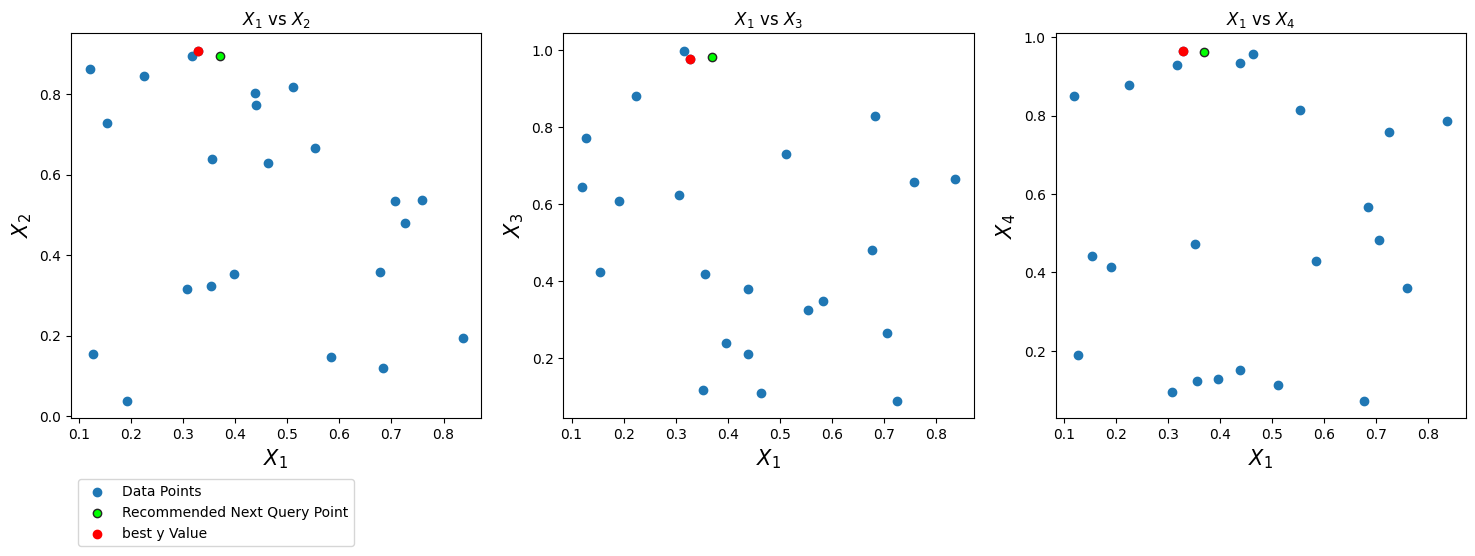

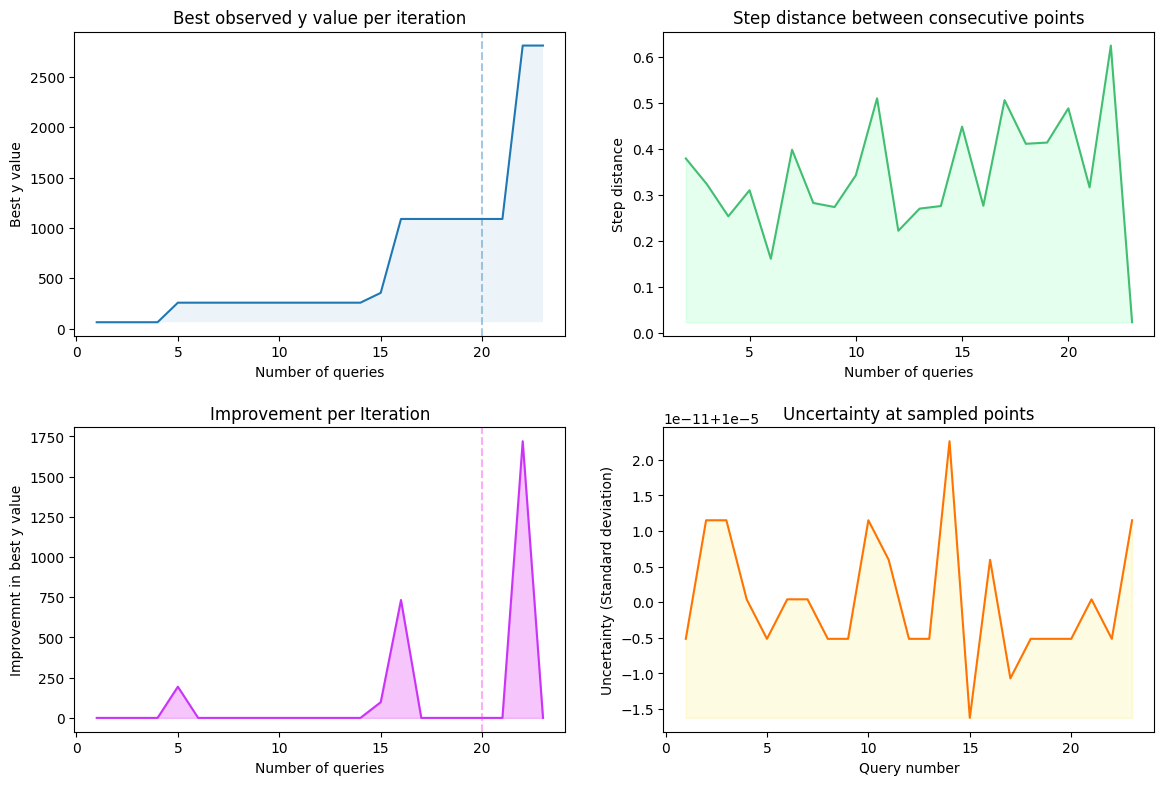

In [14]:
# Defining GP model and fitting to data
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

kernel = ConstantKernel(1.0) * RBF(length_scale=1)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=12) # Look at parameters, some are interesting like normalise y.

model = gpr.fit(X, y_scaled)

# Generating candidate points (random sampling - scales better in higher dimensions)
sampler = qmc.Sobol(4) # Using smarter sampling
X_candidates = sampler.random(2**15)

# GP predictions
mu, sigma = model.predict(X_candidates, return_std=True)

# Acquisition function (UCB)
kappa = 0.5
acquisition_function = mu + kappa * sigma 

# Pick next point
x_next = X_candidates[np.argmax(acquisition_function)]
print('The next query point is:', np.round(x_next,6))

submission = f"{x_next[0]:.6f}-{x_next[1]:.6f}-{x_next[2]:.6f}-{x_next[3]:.6f}"
print('\nSubmission format:       ', submission)


# ==== Metrics ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

# Best value
best_value5_rolling = np.maximum.accumulate(y)   #Returns a rolling value of the best observed y value
best_value5 = max(best_value5_rolling)           #Returns the value of the best observed y value
best_value5_index = best_value5_rolling.argmax() #Returns the index of the best observed y value
best_value5_inputs = X[best_value5_index]        #Returns the inputs that correspond to the best observed y value

print(f'\nThe best y value observed so far is: {best_value5} at iteration {best_value5_index + 1}, with inputs {best_value5_inputs}')

# Improvement per step
best_previous = np.roll(best_value5_rolling, 1)
best_previous[0] = y[0]

improvement = np.maximum(0, y - best_previous)

# Distance between sampled points
distances = pdist(X, 'euclidean')
avg_distances = np.mean(distances)
min_distance = np.min(distances)

# Step distance between consecutive points
step_dist = np.zeros((len(X)+1))
step_dist[:2] = np.nan
for i in range(1, len(X)):
    step_dist[i+1] = np.linalg.norm(X[i] - X[i-1])
step_dist_normalised = step_dist / np.sqrt(4)
step_dist_min = step_dist_normalised[2:].min()

# Uncertainty at sampled points
mu_selected, sigma_selected = model.predict(X, return_std=True)



# ==== Visualisation ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾


# Pair scatter plots
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

fig, axes = plt.subplots(1,3, figsize=(18, 5))

axes[0].scatter(X[:,0], X[:,1], label='Data Points')
axes[0].scatter(x_next[0], x_next[1], c='#00FF00', label='Recommended Next Query Point', edgecolors='#252525')
axes[0].scatter(best_value5_inputs[0], best_value5_inputs[1], c='red', label='best y Value')
axes[0].set_xlabel('$X_1$', size=15)
axes[0].set_ylabel('$X_2$', size=15)
axes[0].set_title('$X_1$ vs $X_2$')
axes[0].legend(loc='upper left', bbox_to_anchor=(0, -0.14))


axes[1].scatter(X[:,0], X[:,2])
axes[1].scatter(x_next[0], x_next[2], c='#00FF00', edgecolors='#252525')
axes[1].scatter(best_value5_inputs[0], best_value5_inputs[2], c='red', label='best y Value')
axes[1].set_xlabel('$X_1$',size=15)
axes[1].set_ylabel('$X_3$',size=15)
axes[1].set_title('$X_1$ vs $X_3$')

axes[2].scatter(X[:,0], X[:,3])
axes[2].scatter(x_next[0], x_next[3], c='#00FF00', edgecolors='#252525')
axes[2].scatter(best_value5_inputs[0], best_value5_inputs[3], c='red', label='best y Value')
axes[2].set_xlabel('$X_1$',size=15)
axes[2].set_ylabel('$X_4$',size=15)
axes[2].set_title('$X_1$ vs $X_4$')

# Performance tracking plots
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

fig, axes = plt.subplots(2,2, figsize=(18, 10))

# Optimisation curve
axes[0,0].plot(np.arange(1,len(X)+1,1), best_value5_rolling)
axes[0,0].axvline(20, linestyle='--', alpha=0.4)
axes[0,0].set_xlabel('Number of queries')
axes[0,0].set_ylabel('Best y value')
axes[0,0].set_title('Best observed y value per iteration')
axes[0,0].fill_between(np.arange(1,len(X)+1,1), best_value5_rolling, best_value5_rolling.min(), alpha=0.08)

# Improvement per step
axes[1,0].plot(np.arange(1,len(X)+1,1), improvement, color="#CA33F8")
axes[1,0].axvline(20, linestyle='--', color="#F833EE",alpha=0.4)
axes[1,0].set_xlabel('Number of queries')
axes[1,0].set_ylabel('Improvemnt in best y value')
axes[1,0].set_title('Improvement per Iteration')
axes[1,0].fill_between(np.arange(1,len(X)+1,1), improvement, improvement.min(), color="#E040F5", alpha=0.3)

# Step distances
axes[0,1].plot(step_dist_normalised, c="#41BE71")
axes[0,1].set_xlabel('Number of queries')
axes[0,1].set_ylabel('Step distance')
axes[0,1].set_title('Step distance between consecutive points')
axes[0,1].fill_between(np.arange(0,len(step_dist),1), step_dist_normalised, step_dist_min, color='#05FF65',alpha=0.1)

# Uncertainty at sampled points
axes[1,1].plot(np.arange(1,len(sigma_selected)+1,1), sigma_selected, c="#FF7300")
axes[1,1].set_xlabel('Query number')
axes[1,1].set_ylabel('Uncertainty (Standard deviation)')
axes[1,1].set_title('Uncertainty at sampled points')
axes[1,1].fill_between(np.arange(1,len(sigma_selected)+1,1), sigma_selected, sigma_selected.min(), color="#F8E539", alpha=0.15)

# Formatting plots
plt.subplots_adjust(
    left=0.2,
    right=0.8,
    top=0.85,
    bottom=0.15,
    hspace=0.3,
    wspace=0.2
)

plt.show()

## Function 6

**5-dimensional**

You’re optimising a cake recipe using a black-box function with five ingredient inputs, for example flour, sugar, eggs, butter and milk. Each recipe is evaluated with a combined score based on flavour, consistency, calories, waste and cost, where each factor contributes negative points as judged by an expert taster. This means the total score is negative by design. 
To frame this as a maximisation problem, your goal is to bring that score as close to zero as possible or, equivalently, to maximise the negative of the total sum.

**Approach**:

Start with high kappa. RBF kernel.

In [15]:
function6_inputs = np.load('C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/Week 4/Function 6/function6_inputs_week4.npy')
print('Inputs: \n', function6_inputs)

function6_outputs = np.load('C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/Week 4/Function 6/function6_outputs_week4.npy')
print('Outputs: \n',function6_outputs)

X = function6_inputs
y = function6_outputs

print(len(X), len(y))

y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.reshape(-1,1)).ravel()

Inputs: 
 [[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.70499988 0.61496184]
 [0.

The next query point is: [0.400454 0.32764  0.653116 0.915262 0.23635 ]

Submission format:        0.400454-0.327640-0.653116-0.915262-0.236350

The best y value observed so far is: -0.2967920323841292 at iteration 23, with inputs [0.399104 0.391975 0.509423 0.706247 0.148625]


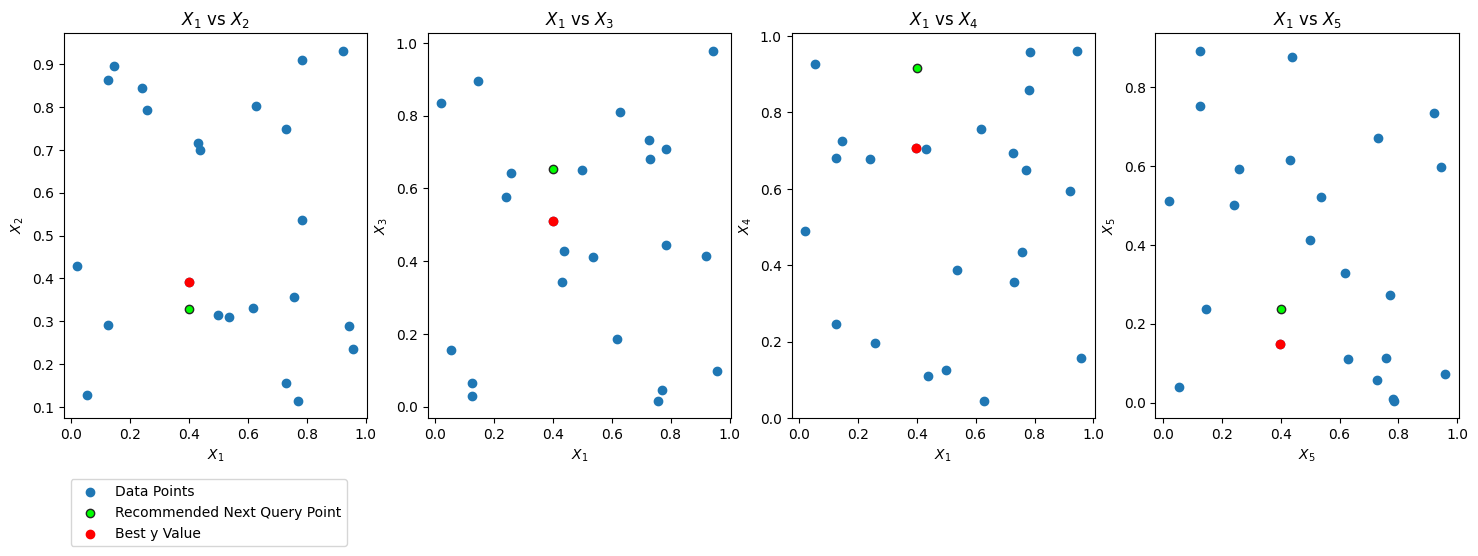

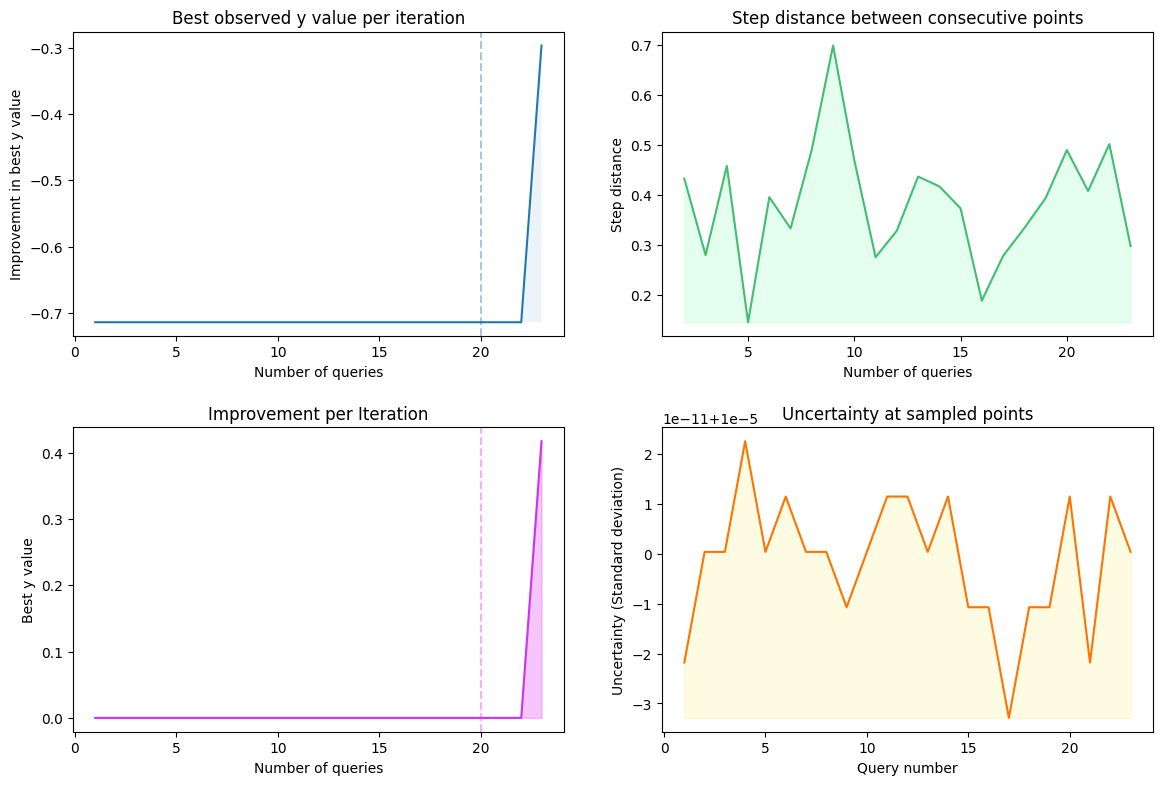

In [16]:
# Defining GP model and fitting to data
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

kernel = ConstantKernel(1.0) * RBF(length_scale=1)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9) # Look at parameters, some are interesting like normalise y.

model = gpr.fit(X, y_scaled)

# Generating candidate points
sampler = qmc.Sobol(5) # Using smarter sampling
X_candidates = sampler.random(2**15)

# GP predictions
mu, sigma = model.predict(X_candidates, return_std=True)

# Acquisition function (UCB)
kappa = 1.5
acquisition_function = mu + kappa * sigma 

# Pick next point
x_next = X_candidates[np.argmax(acquisition_function)]
print('The next query point is:', np.round(x_next,6))

submission = f"{x_next[0]:.6f}-{x_next[1]:.6f}-{x_next[2]:.6f}-{x_next[3]:.6f}-{x_next[4]:.6f}"
print('\nSubmission format:       ', submission)


# ==== Metrics ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

# Best value
best_value6_rolling = np.maximum.accumulate(y)   #Returns a rolling value of the best observed y value
best_value6 = max(best_value6_rolling)           #Returns the value of the best observed y value
best_value6_index = best_value6_rolling.argmax() #Returns the index of the best observed y value
best_value6_inputs = X[best_value6_index]        #Returns the inputs that correspond to the best observed y value

print(f'\nThe best y value observed so far is: {best_value6} at iteration {best_value6_index + 1}, with inputs {best_value6_inputs}')

# Improvement per step
best_previous = np.roll(best_value6_rolling, 1)
best_previous[0] = y[0]

improvement = np.maximum(0, y - best_previous)

# Distance between sampled points
distances = pdist(X)
avg_distances = np.mean(distances)
min_distance = np.min(distances)

# Step distance between consecutive points
step_dist = np.zeros((len(X)+1))
step_dist[:2] = np.nan
for i in range(1, len(X)):
    step_dist[i+1] = np.linalg.norm(X[i] - X[i-1])
step_dist_normalised = step_dist / np.sqrt(5)
step_dist_min = step_dist_normalised[2:].min()

# Uncertainty at sampled points
mu_selected, sigma_selected = model.predict(X, return_std=True)



# ==== Visualisation ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

# Pair scatter plots
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

fig, axes = plt.subplots(1,4, figsize=(18, 5))

axes[0].scatter(X[:,0], X[:,1], label='Data Points')
axes[0].scatter(x_next[0], x_next[1], c='#00FF00', label='Recommended Next Query Point', edgecolors='#252525')
axes[0].scatter(best_value6_inputs[0], best_value6_inputs[1], c='red', label='Best y Value')
axes[0].set_xlabel('$X_1$')
axes[0].set_ylabel('$X_2$')
axes[0].set_title('$X_1$ vs $X_2$')
axes[0].legend(loc='upper left', bbox_to_anchor=(0, -0.14))

axes[1].scatter(X[:,0], X[:,2])
axes[1].scatter(x_next[0], x_next[2], c='#00FF00', edgecolors='#252525')
axes[1].scatter(best_value6_inputs[0], best_value6_inputs[2], c='red', label='Best y Value')
axes[1].set_xlabel('$X_1$')
axes[1].set_ylabel('$X_3$')
axes[1].set_title('$X_1$ vs $X_3$')

axes[2].scatter(X[:,0], X[:,3])
axes[2].scatter(x_next[0], x_next[3], c='#00FF00', edgecolors='#252525')
axes[2].scatter(best_value6_inputs[0], best_value6_inputs[3], c='red', label='Best y Value')
axes[2].set_xlabel('$X_1$')
axes[2].set_ylabel('$X_4$')
axes[2].set_title('$X_1$ vs $X_4$')

axes[3].scatter(X[:,0], X[:,4])
axes[3].scatter(x_next[0], x_next[4], c='#00FF00', edgecolors='#252525')
axes[3].scatter(best_value6_inputs[0], best_value6_inputs[4], c='red', label='Best y Value')
axes[3].set_xlabel('$X_5$')
axes[3].set_ylabel('$X_5$')
axes[3].set_title('$X_1$ vs $X_5$')

# Performance tracking plots
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

fig, axes = plt.subplots(2,2, figsize=(18, 10))

# Optimisation curve
axes[0,0].plot(np.arange(1,len(X)+1,1), best_value6_rolling)
axes[0,0].axvline(20, linestyle='--', alpha=0.4)
axes[0,0].set_xlabel('Number of queries')
axes[0,0].set_ylabel('Improvemnt in best y value')
axes[0,0].set_title('Best observed y value per iteration')
axes[0,0].fill_between(np.arange(1,len(X)+1,1), best_value6_rolling, best_value6_rolling.min(), alpha=0.08)

# Improvement per step
axes[1,0].plot(np.arange(1,len(X)+1,1), improvement, color="#CA33F8")
axes[1,0].axvline(20, linestyle='--', color="#F833EE",alpha=0.4)
axes[1,0].set_xlabel('Number of queries')
axes[1,0].set_ylabel('Best y value')
axes[1,0].set_title('Improvement per Iteration')
axes[1,0].fill_between(np.arange(1,len(X)+1,1), improvement, improvement.min(), color="#E040F5", alpha=0.3)

# Step distances
axes[0,1].plot(step_dist_normalised, c="#41BE71")
axes[0,1].set_xlabel('Number of queries')
axes[0,1].set_ylabel('Step distance')
axes[0,1].set_title('Step distance between consecutive points')
axes[0,1].fill_between(np.arange(0,len(step_dist),1), step_dist_normalised, step_dist_min, color='#05FF65',alpha=0.1)

# Uncertainty at sampled points
axes[1,1].plot(np.arange(1,len(sigma_selected)+1,1), sigma_selected, c="#FF7300")
axes[1,1].set_xlabel('Query number')
axes[1,1].set_ylabel('Uncertainty (Standard deviation)')
axes[1,1].set_title('Uncertainty at sampled points')
axes[1,1].fill_between(np.arange(1,len(sigma_selected)+1,1), sigma_selected, sigma_selected.min(), color="#F8E539", alpha=0.15)

# Formatting plots
plt.subplots_adjust(
    left=0.2,
    right=0.8,
    top=0.85,
    bottom=0.15,
    hspace=0.3,
    wspace=0.2
)

plt.show()

## Function 7

**6-dimensional**

You’re tasked with optimising an ML model by tuning six hyperparameters, for example learning rate, regularisation strength or number of hidden layers. The function you’re maximising is the model’s performance score (such as accuracy or F1), but since the relationship between inputs and output isn’t known, it’s treated as a black-box function. 
Because this is a commonly used model, you might benefit from researching best practices or literature to guide your initial search space. Your goal is to find the combination of hyperparameters that yields the highest possible performance.

**Approach**:

Likely start with high kappa, potentially use Matern kernel.

Look up best practices for this.

In [17]:
function7_inputs = np.load('C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/Week 4/Function 7/function7_inputs_week4.npy')
print('Inputs: \n', function7_inputs)

function7_outputs = np.load('C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/Week 4/Function 7/function7_outputs_week4.npy')
print('Outputs: \n',function7_outputs)

X = function7_inputs
y = function7_outputs

print(len(X), len(y))

y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.reshape(-1,1)).ravel()

Inputs: 
 [[0.27262382 0.32449536 0.89710881 0.83295115 0.15406269 0.79586362]
 [0.54300258 0.9246939  0.34156746 0.64648585 0.71844033 0.34313266]
 [0.09083225 0.66152938 0.06593091 0.25857701 0.96345285 0.6402654 ]
 [0.11886697 0.61505494 0.90581639 0.8553003  0.41363143 0.58523563]
 [0.63021764 0.8380969  0.68001305 0.73189509 0.52673671 0.34842921]
 [0.76491917 0.25588292 0.60908422 0.21807904 0.32294277 0.09579366]
 [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
 [0.19525188 0.07922665 0.55458046 0.17056682 0.01494418 0.10703171]
 [0.64230298 0.83687455 0.02179269 0.10148801 0.68307083 0.6924164 ]
 [0.78994255 0.19554501 0.57562333 0.07365919 0.25904917 0.05109986]
 [0.52849733 0.45742436 0.36009569 0.36204551 0.81689098 0.63747637]
 [0.72261522 0.01181284 0.06364591 0.16517311 0.07924415 0.35995166]
 [0.07566492 0.33450212 0.13273274 0.60831236 0.91838592 0.82233079]
 [0.94245084 0.37743962 0.48612233 0.22879108 0.08263175 0.71195755]
 [0.14864702 0.03394336 

The next query point is: [0.033248 0.479355 0.417031 0.228403 0.352995 0.620073]

Submission format:        0.033248-0.479355-0.417031-0.228403-0.352995-0.620073

The best y value observed so far is: 1.7349317990608195 at iteration 33, with inputs [0.017819 0.449843 0.3527   0.208615 0.388465 0.711739]


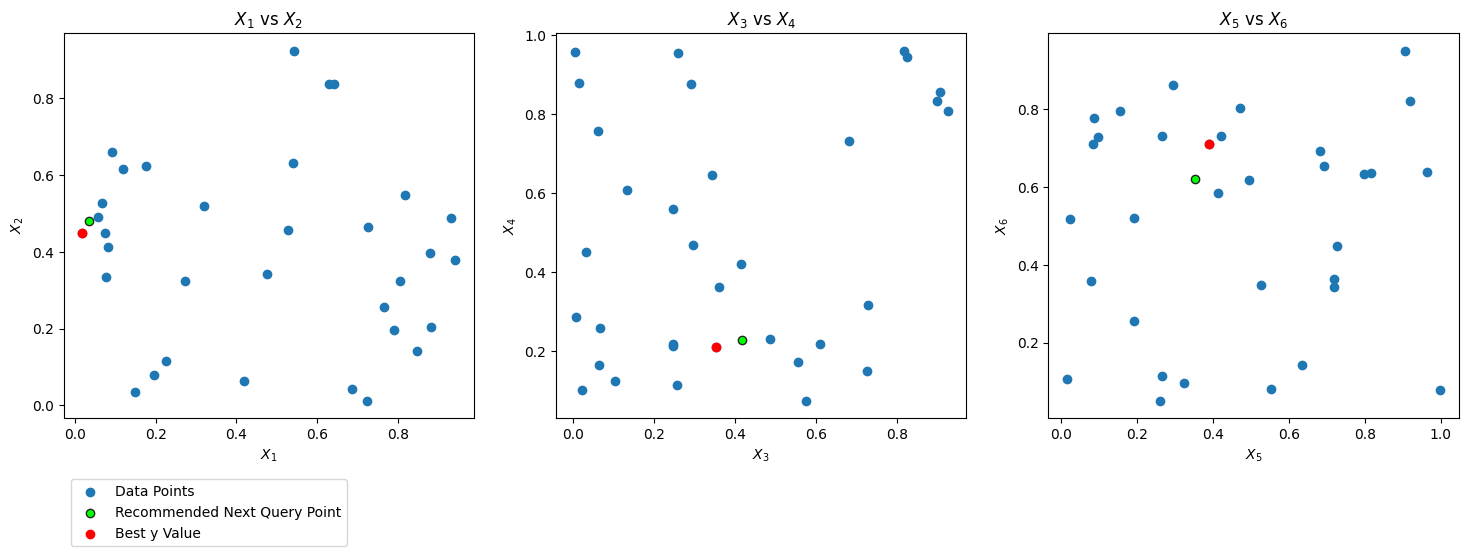

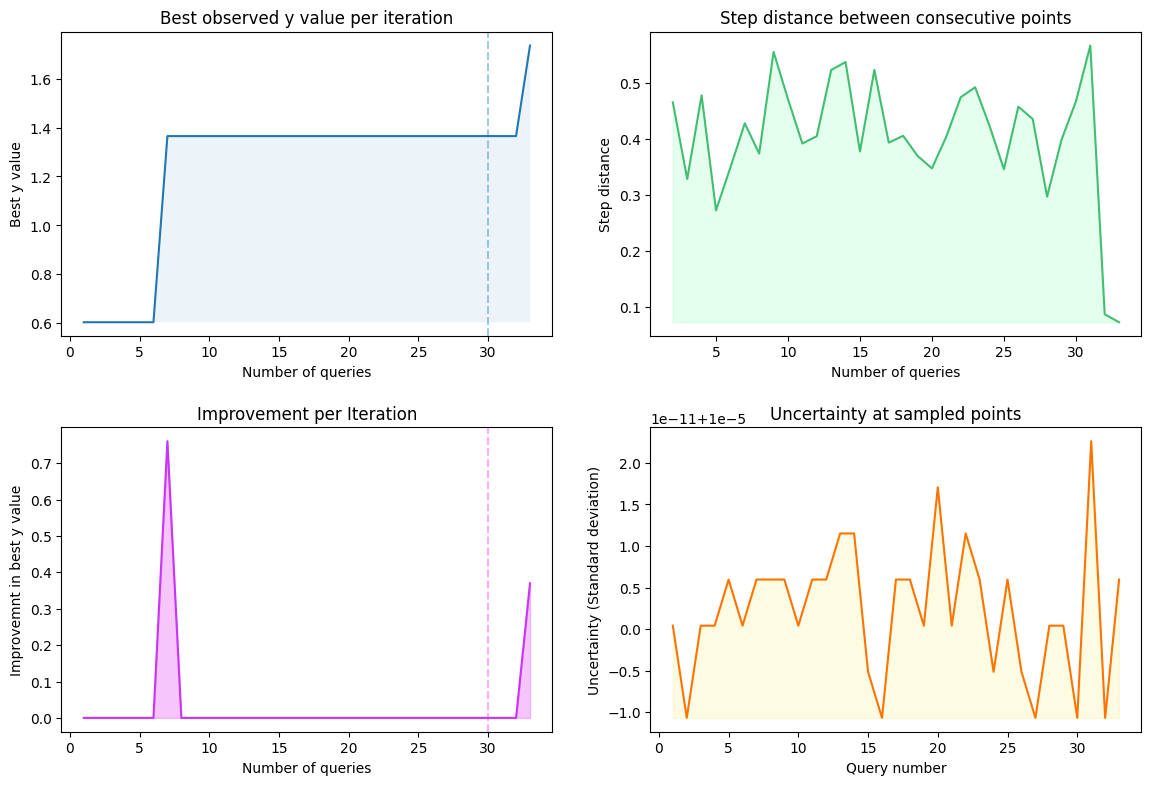

In [18]:
# Defining GP model and fitting to data
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

kernel = ConstantKernel(1.0) * Matern(length_scale=1, nu=2.5)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9) # Look at parameters, some are interesting like normalise y.

model = gpr.fit(X, y_scaled)

# Generating candidate points (grid search)
sampler = qmc.Sobol(6) # Using smarter sampling
X_candidates = sampler.random(2**15)

# GP predictions
mu, sigma = model.predict(X_candidates, return_std=True)

# Acquisition function (UCB)
kappa = 1.5
acquisition_function = mu + kappa * sigma 

# Pick next point
x_next = X_candidates[np.argmax(acquisition_function)]
print('The next query point is:', np.round(x_next,6))

submission = f"{x_next[0]:.6f}-{x_next[1]:.6f}-{x_next[2]:.6f}-{x_next[3]:.6f}-{x_next[4]:.6f}-{x_next[5]:.6f}"
print('\nSubmission format:       ', submission)


# ==== Metrics ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

# Best value
best_value7_rolling = np.maximum.accumulate(y)   #Returns a rolling value of the best observed y value
best_value7 = max(best_value7_rolling)           #Returns the value of the best observed y value
best_value7_index = best_value7_rolling.argmax() #Returns the index of the best observed y value
best_value7_inputs = X[best_value7_index]        #Returns the inputs that correspond to the best observed y value

print(f'\nThe best y value observed so far is: {best_value7} at iteration {best_value7_index + 1}, with inputs {best_value7_inputs}')

# Improvement per step
best_previous = np.roll(best_value7_rolling, 1)
best_previous[0] = y[0]

improvement = np.maximum(0, y - best_previous)


# Distance between sampled points
distances = pdist(X)
avg_distances = np.mean(distances)
min_distance = np.min(distances)

# Step distance between consecutive points
step_dist = np.zeros((len(X)+1))
step_dist[:2] = np.nan
for i in range(1, len(X)):
    step_dist[i+1] = np.linalg.norm(X[i] - X[i-1])
step_dist_normalised = step_dist / np.sqrt(6)
step_dist_min = step_dist_normalised[2:].min()

# Uncertainty at sampled points
mu_selected, sigma_selected = model.predict(X, return_std=True)


# ==== Visualisation ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾


# Scatter plots
# ‾‾‾‾‾‾‾‾‾‾‾‾‾

fig, axes = plt.subplots(1,3, figsize=(18, 5))

axes[0].scatter(X[:,0], X[:,1], label='Data Points')
axes[0].scatter(x_next[0], x_next[1], c='#00FF00', label='Recommended Next Query Point', edgecolors='#252525')
axes[0].scatter(best_value7_inputs[0], best_value7_inputs[1], c='red', label='Best y Value')
axes[0].set_xlabel('$X_1$')
axes[0].set_ylabel('$X_2$')
axes[0].set_title('$X_1$ vs $X_2$')
axes[0].legend(loc='upper left', bbox_to_anchor=(0, -0.14))

axes[1].scatter(X[:,2], X[:,3])
axes[1].scatter(x_next[2], x_next[3], c='#00FF00', edgecolors='#252525')
axes[1].scatter(best_value7_inputs[2], best_value7_inputs[3], c='red')
axes[1].set_xlabel('$X_3$')
axes[1].set_ylabel('$X_4$')
axes[1].set_title('$X_3$ vs $X_4$')

axes[2].scatter(X[:,4], X[:,5])
axes[2].scatter(x_next[4], x_next[5], c='#00FF00', edgecolors='#252525')
axes[2].scatter(best_value7_inputs[4], best_value7_inputs[5], c='red')
axes[2].set_xlabel('$X_5$')
axes[2].set_ylabel('$X_6$')
axes[2].set_title('$X_5$ vs $X_6$')

# Performance tracking plots
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

fig, axes = plt.subplots(2,2, figsize=(18, 10))

# Optimisation curve
axes[0,0].plot(np.arange(1,len(X)+1,1), best_value7_rolling)
axes[0,0].axvline(30, linestyle='--', alpha=0.4)
axes[0,0].set_xlabel('Number of queries')
axes[0,0].set_ylabel('Best y value')
axes[0,0].set_title('Best observed y value per iteration')
axes[0,0].fill_between(np.arange(1,len(X)+1,1), best_value7_rolling, best_value7_rolling.min(), alpha=0.08)

# Improvement per step
axes[1,0].plot(np.arange(1,len(X)+1,1), improvement, color="#CA33F8")
axes[1,0].axvline(30, linestyle='--', color="#F833EE",alpha=0.4)
axes[1,0].set_xlabel('Number of queries')
axes[1,0].set_ylabel('Improvemnt in best y value')
axes[1,0].set_title('Improvement per Iteration')
axes[1,0].fill_between(np.arange(1,len(X)+1,1), improvement, improvement.min(), color="#E040F5", alpha=0.3)

# Step distances
axes[0,1].plot(step_dist_normalised, c="#41BE71")
axes[0,1].set_xlabel('Number of queries')
axes[0,1].set_ylabel('Step distance')
axes[0,1].set_title('Step distance between consecutive points')
axes[0,1].fill_between(np.arange(0,len(step_dist),1), step_dist_normalised, step_dist_min, color='#05FF65',alpha=0.1)

# Uncertainty at sampled points
axes[1,1].plot(np.arange(1,len(sigma_selected)+1,1), sigma_selected, c="#FF7300")
axes[1,1].set_xlabel('Query number')
axes[1,1].set_ylabel('Uncertainty (Standard deviation)')
axes[1,1].set_title('Uncertainty at sampled points')
axes[1,1].fill_between(np.arange(1,len(sigma_selected)+1,1), sigma_selected, sigma_selected.min(), color="#F8E539", alpha=0.15)

# Formatting plots
plt.subplots_adjust(
    left=0.2,
    right=0.8,
    top=0.85,
    bottom=0.15,
    hspace=0.3,
    wspace=0.2
)

plt.show()

## Function 8

**8-dimensional**

You’re optimising an eight-dimensional black-box function, where each of the eight input parameters affects the output, but the internal mechanics are unknown. 
Your objective is to find the parameter combination that maximises the function’s output, such as performance, efficiency or validation accuracy. Because the function is high-dimensional and likely complex, global optimisation is hard, so identifying strong local maxima is often a practical strategy.

For example, imagine you’re tuning an ML model with eight hyperparameters: learning rate, batch size, number of layers, dropout rate, regularisation strength, activation function (numerically encoded), optimiser type (encoded) and initial weight range. Each input set returns a single validation accuracy score between 0 and 1. Your goal is to maximise this score.

**Approach**:

Likely to be lots of local maximum, start with high kappa + random search, using matern kernel.

In [19]:
function8_inputs = np.load('C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/Week 4/Function 8/function8_inputs_week4.npy')
print('Inputs: \n', function8_inputs)

function8_outputs = np.load('C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/Week 4/Function 8/function8_outputs_week4.npy')
print('Outputs: \n',function8_outputs)

X = function8_inputs
y = function8_outputs

print(len(X), len(y))

y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.reshape(-1,1)).ravel()

Inputs: 
 [[0.60499445 0.29221502 0.90845275 0.35550624 0.20166872 0.57533801
  0.31031095 0.73428138]
 [0.17800696 0.56622265 0.99486184 0.21032501 0.32015266 0.70790879
  0.63538449 0.10713163]
 [0.00907698 0.81162615 0.52052036 0.07568668 0.26511183 0.09165169
  0.59241515 0.36732026]
 [0.50602816 0.65373012 0.36341078 0.17798105 0.0937283  0.19742533
  0.7558269  0.29247234]
 [0.35990926 0.24907568 0.49599717 0.70921498 0.11498719 0.28920692
  0.55729515 0.59388173]
 [0.77881834 0.0034195  0.33798313 0.51952778 0.82090699 0.53724669
  0.5513471  0.66003209]
 [0.90864932 0.0622497  0.23825955 0.76660355 0.13233596 0.99024381
  0.68806782 0.74249594]
 [0.58637144 0.88073573 0.74502075 0.54603485 0.00964888 0.74899176
  0.23090707 0.09791562]
 [0.76113733 0.85467239 0.38212433 0.33735198 0.68970832 0.30985305
  0.63137968 0.04195607]
 [0.9849332  0.69950626 0.9988855  0.18014846 0.58014315 0.23108719
  0.49082694 0.31368272]
 [0.11207131 0.43773566 0.59659878 0.59277563 0.22698177 0.4

The next query point is: [0.00441  0.201693 0.004998 0.161973 0.25714  0.498227 0.129442 0.997268]

Submission format:        0.004410-0.201693-0.004998-0.161973-0.257140-0.498227-0.129442-0.997268

The best y value observed so far is: 9.7772314276134 at iteration 41, with inputs [0.164299 0.145994 0.036325 0.102718 0.889143 0.121907 0.06037  0.594931]


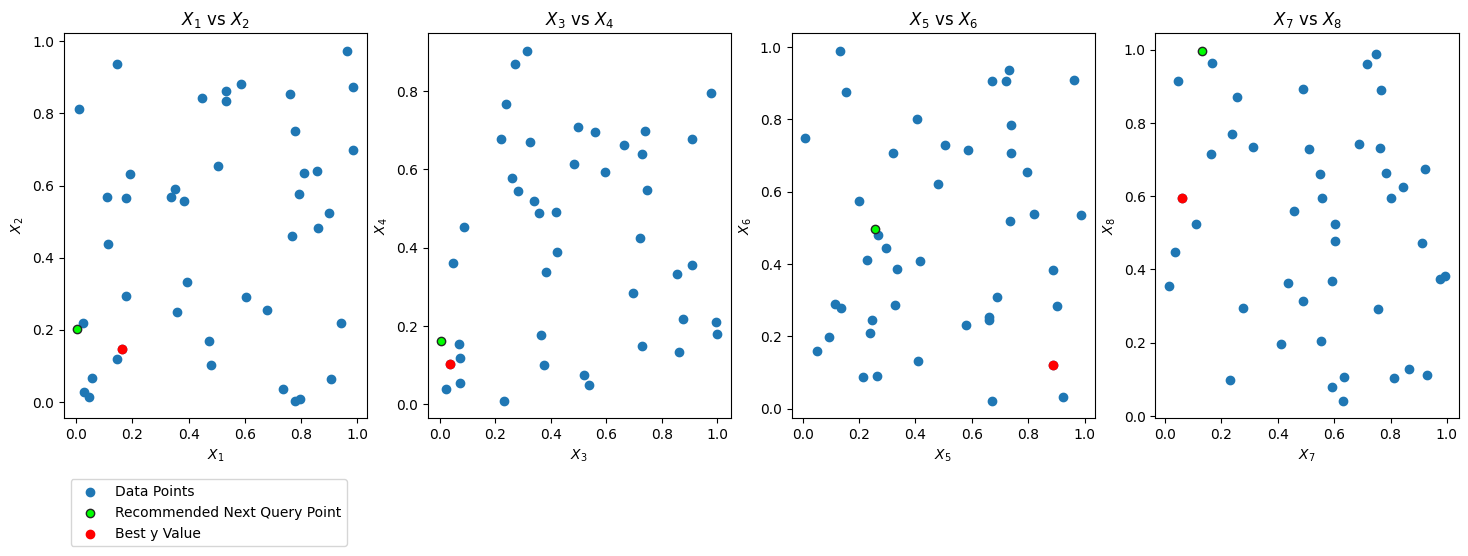

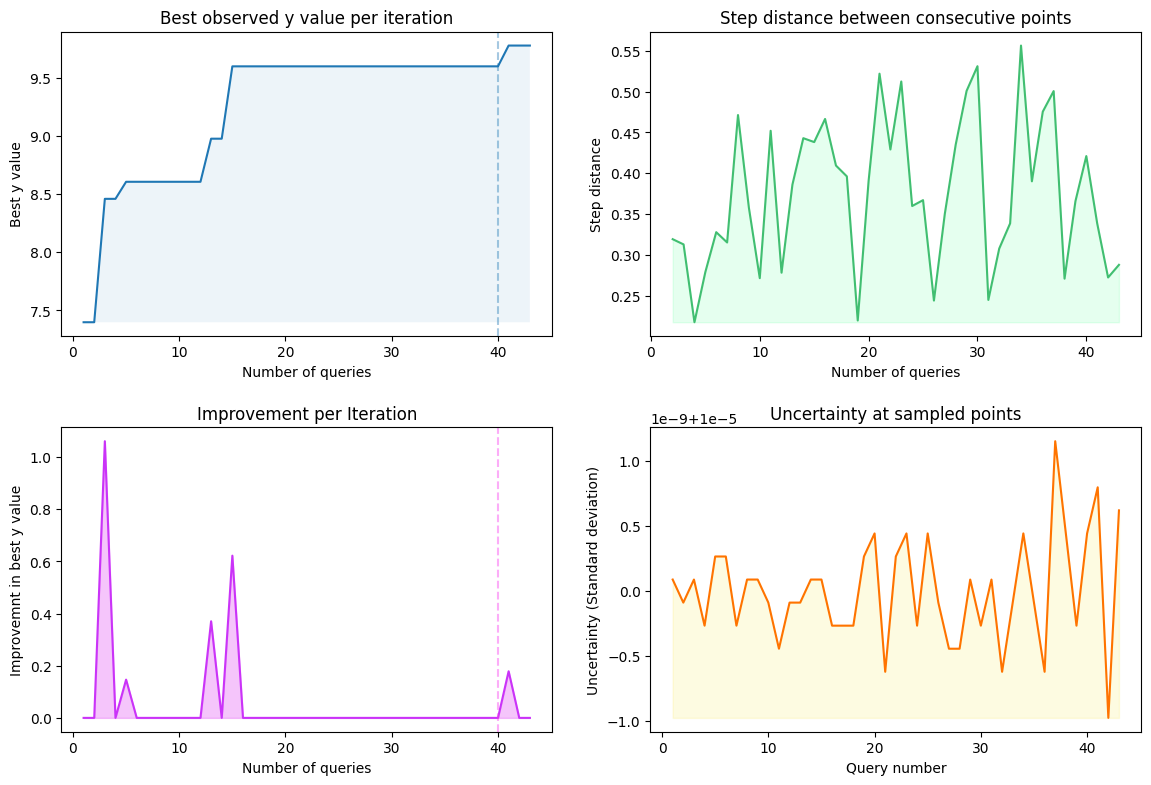

In [20]:
# Defining GP model and fitting to data
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

kernel = ConstantKernel(1.0) * Matern(length_scale=1, nu=2.5)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9) # Look at parameters, some are interesting like normalise y.

model = gpr.fit(X, y_scaled)

# Generating candidate points
sampler = qmc.Sobol(8) # Using smarter sampling
X_candidates = sampler.random(2**15)

# GP predictions
mu, sigma = model.predict(X_candidates, return_std=True)

# Acquisition function (UCB)
kappa = 1.5
acquisition_function = mu + kappa * sigma 

# Pick next point
x_next = X_candidates[np.argmax(acquisition_function)]
print('The next query point is:', np.round(x_next,6))

submission = f"{x_next[0]:.6f}-{x_next[1]:.6f}-{x_next[2]:.6f}-{x_next[3]:.6f}-{x_next[4]:.6f}-{x_next[5]:.6f}-{x_next[6]:.6f}-{x_next[7]:.6f}"
print('\nSubmission format:       ', submission)


# ==== Metrics ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

# Best value
best_value8_rolling = np.maximum.accumulate(y)   #Returns a rolling value of the best observed y value
best_value8 = max(best_value8_rolling)           #Returns the value of the best observed y value
best_value8_index = best_value8_rolling.argmax() #Returns the index of the best observed y value
best_value8_inputs = X[best_value8_index]        #Returns the inputs that correspond to the best observed y value

print(f'\nThe best y value observed so far is: {best_value8} at iteration {best_value8_index + 1}, with inputs {best_value8_inputs}')

# Improvement per step
best_previous = np.roll(best_value8_rolling, 1)
best_previous[0] = y[0]

improvement = np.maximum(0, y - best_previous)

# Distance between sampled points
distances = pdist(X)
avg_distances = np.mean(distances)
min_distance = np.min(distances)

# Step distance between consecutive points
step_dist = np.zeros((len(X)+1))
step_dist[:2] = np.nan
for i in range(1, len(X)):
    step_dist[i+1] = np.linalg.norm(X[i] - X[i-1])
step_dist_normalised = step_dist / np.sqrt(8)
step_dist_min = step_dist_normalised[2:].min()

# Uncertainty at sampled points
mu_selected, sigma_selected = model.predict(X, return_std=True)



# ==== Visualisation ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾


# Scatter plots
# ‾‾‾‾‾‾‾‾‾‾‾‾‾

fig, axes = plt.subplots(1,4, figsize=(18, 5))

axes[0].scatter(X[:,0], X[:,1], label='Data Points')
axes[0].scatter(x_next[0], x_next[1], c='#00FF00', label='Recommended Next Query Point', edgecolors='#252525')
axes[0].scatter(best_value8_inputs[0], best_value8_inputs[1], c='red', label='Best y Value')
axes[0].set_xlabel('$X_1$')
axes[0].set_ylabel('$X_2$')
axes[0].set_title('$X_1$ vs $X_2$')
axes[0].legend(loc='upper left', bbox_to_anchor=(0, -0.14))

axes[1].scatter(X[:,2], X[:,3])
axes[1].scatter(x_next[2], x_next[3], c='#00FF00', edgecolors='#252525')
axes[1].scatter(best_value8_inputs[2], best_value8_inputs[3], c='red')
axes[1].set_xlabel('$X_3$')
axes[1].set_ylabel('$X_4$')
axes[1].set_title('$X_3$ vs $X_4$')

axes[2].scatter(X[:,4], X[:,5])
axes[2].scatter(x_next[4], x_next[5], c='#00FF00', edgecolors='#252525')
axes[2].scatter(best_value8_inputs[4], best_value8_inputs[5], c='red')
axes[2].set_xlabel('$X_5$')
axes[2].set_ylabel('$X_6$')
axes[2].set_title('$X_5$ vs $X_6$')

axes[3].scatter(X[:,6], X[:,7])
axes[3].scatter(x_next[6], x_next[7], c='#00FF00', edgecolors='#252525')
axes[3].scatter(best_value8_inputs[6], best_value8_inputs[7], c='red')
axes[3].set_xlabel('$X_7$')
axes[3].set_ylabel('$X_8$')
axes[3].set_title('$X_7$ vs $X_8$')

# Performance tracking plots
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

fig, axes = plt.subplots(2,2, figsize=(18, 10))

# Optimisation curve
axes[0,0].plot(np.arange(1,len(X)+1,1), best_value8_rolling)
axes[0,0].axvline(40, linestyle='--', alpha=0.4)
axes[0,0].set_xlabel('Number of queries')
axes[0,0].set_ylabel('Best y value')
axes[0,0].set_title('Best observed y value per iteration')
axes[0,0].fill_between(np.arange(1,len(X)+1,1), best_value8_rolling, best_value8_rolling.min(), alpha=0.08)

# Improvement per step
axes[1,0].plot(np.arange(1,len(X)+1,1), improvement, color="#CA33F8")
axes[1,0].axvline(40, linestyle='--', color="#F833EE",alpha=0.4)
axes[1,0].set_xlabel('Number of queries')
axes[1,0].set_ylabel('Improvemnt in best y value')
axes[1,0].set_title('Improvement per Iteration')
axes[1,0].fill_between(np.arange(1,len(X)+1,1), improvement, improvement.min(), color="#E040F5", alpha=0.3)

# Step distances
axes[0,1].plot(step_dist_normalised, c="#41BE71")
axes[0,1].set_xlabel('Number of queries')
axes[0,1].set_ylabel('Step distance')
axes[0,1].set_title('Step distance between consecutive points')
axes[0,1].fill_between(np.arange(0,len(step_dist),1), step_dist_normalised, step_dist_min, color='#05FF65',alpha=0.1)

# Uncertainty at sampled points
axes[1,1].plot(np.arange(1,len(sigma_selected)+1,1), sigma_selected, c="#FF7300")
axes[1,1].set_xlabel('Query number')
axes[1,1].set_ylabel('Uncertainty (Standard deviation)')
axes[1,1].set_title('Uncertainty at sampled points')
axes[1,1].fill_between(np.arange(1,len(sigma_selected)+1,1), sigma_selected, sigma_selected.min(), color="#F8E539", alpha=0.15)

# Formatting plots
plt.subplots_adjust(
    left=0.2,
    right=0.8,
    top=0.85,
    bottom=0.15,
    hspace=0.3,
    wspace=0.2
)

plt.show()